In [1]:
import sqlite3
import pandas as pd
from tqdm import tqdm
import powerlaw as pwl
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np


In [2]:
con = sqlite3.connect("vp_data2_isikud.db")
cur = con.cursor()
cur.execute('ATTACH DATABASE "v33.db" AS v33')

## 1. tabel 
## verb -> palju esineb obl+kääne (6 kohakäänet) : mitu matchi ja mitu distinct root 

Võtta välja kõik mis on kohakäändes ja sõna deprel on obl

#### vaade mis on tabelis

In [3]:
tables = cur.execute("""
SELECT * FROM transactions_verbs_obl_kohakaandes_wcomps
limit 10
""")

for i, elem in enumerate(tables):
    print(elem)

(2, 'toimuma', '', 1, 'lõpp', 'obl', 'S', 'com,in,sg', 'UNK', 'UNK', 'in')
(3, 'saama', 'pihta', 7, 'keel', 'obl', 'S', 'all,com,pl', 'UNK', 'UNK', 'all')
(10, 'tulema', '', 19, 'sina', 'obl', 'P', 'ad,sg', 'UNK', 'YES', 'ad')
(11, 'viilima', '', 22, 'tund', 'obl', 'S', 'com,el,pl', 'UNK', 'UNK', 'el')
(11, 'viilima', '', 23, 'juht', 'obl', 'S', 'ad,com,sg', 'UNK', 'YES', 'ad')
(25, 'muutuma', '', 40, 'mis', 'obl', 'P', 'el,sg', 'UNK', 'UNK', 'el')
(33, 'minema', 'peale', 59, 'rahvas', 'obl', 'S', 'all,com,sg', 'UNK', 'UNK', 'all')
(37, 'tekkima', '', 69, 'see', 'obl', 'P', 'el,sg', 'UNK', 'UNK', 'el')
(51, 'kutsuma', '', 85, 'elu', 'obl', 'S', 'adit,com,sg', 'UNK', 'UNK', 'adit')
(53, 'tulema', '', 88, 'toim', 'obl', 'S', 'adit,com,sg', 'UNK', 'UNK', 'adit')


### base tabel, kus on distinct verbid ja distinct root count iga käände jaoks

In [4]:
query = """

SELECT *
from transactions_verbs_obl_kohakaandes_root_counts_distinct_wcomps_v1
"""

source = pd.read_sql_query(query, con)
source

,verb,verb_compound,abl_cnt,adit_cnt,all_cnt,ad_cnt,el_cnt,ill_cnt,in_cnt
0,12olema,,1,0,0,0,0,0,0
1,A. tihkama,,1,0,0,0,0,0,0
2,J. teppima,,1,0,0,0,0,0,0
3,Liitootama,,1,0,0,1,0,0,0
4,Southolema,,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
5651,ütlema,ära,5,2,138,67,488,3,54
5652,üürima,,69,18,107,67,49,9,153
5653,üürima,kokku,1,0,0,0,0,0,0
5654,šantažeerima,välja,1,0,0,0,0,0,0


# analüüs

- mitu nullist erinevat välja?
- mitu välja on 2 ja rohkem? 3 ja rohkem? jne
- teha üldiselt tabeli jaoks
- teha iga käände jaoks eraldi

- joonista teljestikule: power law graph
    - 1 telg on root threshold (1, 2, 3 jne)
    - 2 telg on mitu celli selle väärtusega on

- mitu % on lahreid, kus väärtus on >=10



In [5]:
all_values = list(source["abl_cnt"])+list(source["adit_cnt"])+list(source["all_cnt"])+list(source["ad_cnt"])+list(source["el_cnt"])+list(source["ill_cnt"])+list(source["in_cnt"])

In [6]:
len(all_values)

39592

In [7]:
non_null = [a for a in all_values if a != 0]
print("num non-null values:", len(non_null))

num non-null values: 28569


### mitu % lahtreid, kus väärtus on >=10

In [8]:
# kõikidest lahtritest %
gt10 = [a for a in all_values if a >=10]

print(len(gt10)*100/len(all_values))

30.771367953121842


In [9]:
# non-null lahtritest %
gt10_2 = [a for a in non_null if a >=10]
print(len(gt10_2)*100/len(non_null))

42.6441247506038


# PILDID 1

## üleüldiselt jaotus kui palju on igat väärtust tabelis

In [10]:
jaotus1 = Counter(non_null)
jaotus1 = [(k, v) for k, v in dict(jaotus1).items()]
#jaotus1

In [11]:
df1 = pd.DataFrame(jaotus1,columns=["cell_value", "count"])
df1 = df1.sort_values(by=['cell_value'])

In [12]:
df1

,cell_value,count
0,1,6458
4,2,2897
5,3,1856
6,4,1293
2,5,1069
...,...,...
752,8468,1
1060,8532,1
876,10891,1
330,11612,1


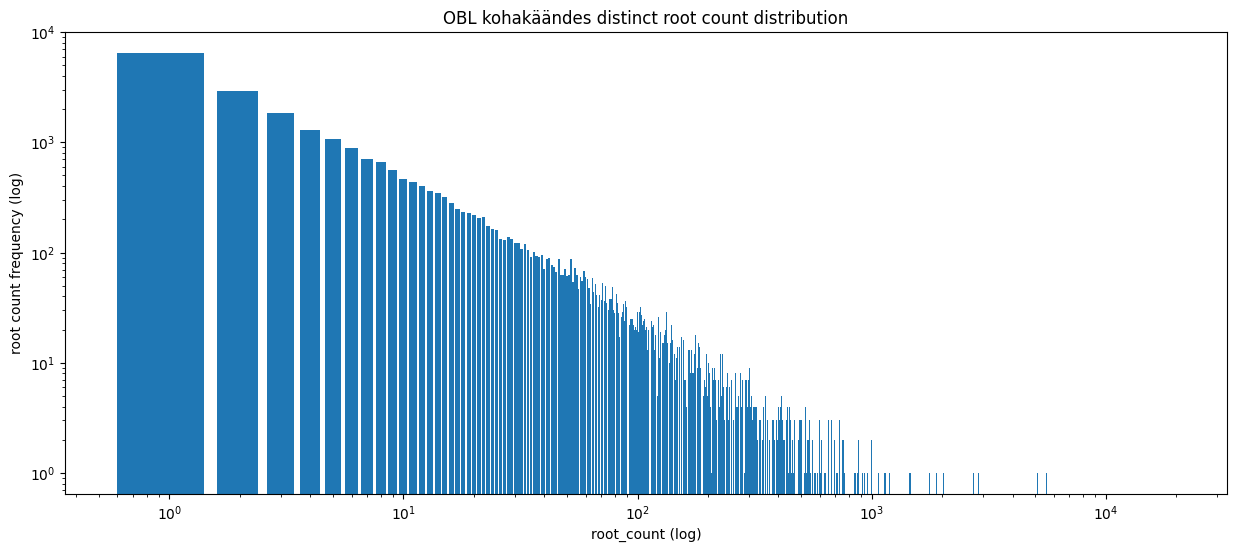

In [13]:
verb_pat_freq = list(df1["cell_value"])
verb_pat_freq2 = [str(e) for e in verb_pat_freq]
counts = list(df1["count"])

plt.figure(figsize=(15,6))
plt.bar(verb_pat_freq, counts)

#percents = list(df1["percentage"])
#for i in range(len(df1)):
#    plt.text(i, df1.iloc[i]["root_count"]+200, str(percents[i])+"%", ha = 'center')

plt.yscale('log')
plt.xscale('log')

plt.title("OBL kohakäändes distinct root count distribution")
plt.ylabel("root count frequency (log)")
plt.xlabel("root_count (log)")
plt.show()

## attempt at power law graph

In [14]:
values = [e for e in non_null]

x = range(max(values) + 1)
# Create a list to store the counts
counts = []

# Calculate the counts for each threshold
for i in tqdm(x):
    count = sum(v > i for v in values)
    counts.append(count)

100%|████████████████████████████████████████████████████| 19633/19633 [00:16<00:00, 1167.00it/s]


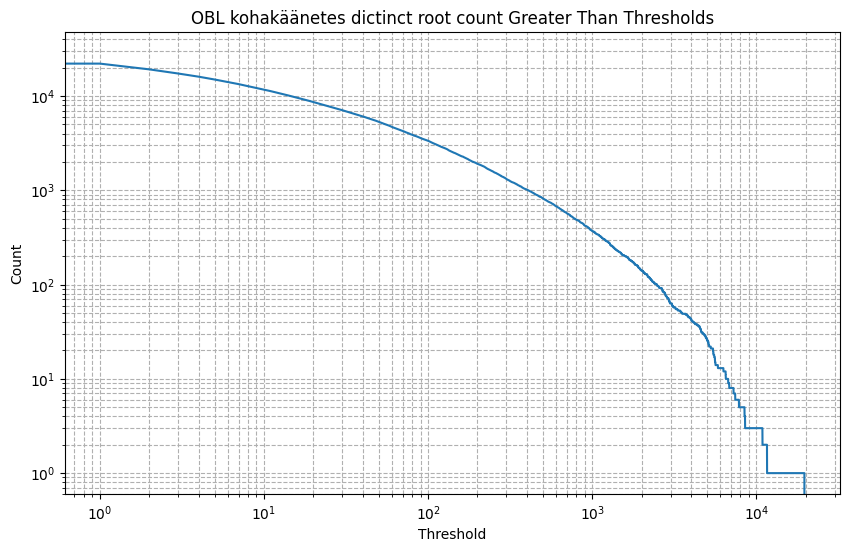

In [15]:
# Convert counts to a numpy array for better handling
counts2 = np.array(counts)

# Plot the power law graph
plt.figure(figsize=(10, 6))
plt.loglog(x, counts)
plt.xlabel('Threshold')
plt.ylabel('Count')
plt.title('OBL kohakäänetes dictinct root count Greater Than Thresholds')
plt.grid(True, which="both", ls="--")
plt.show()


## OBL kohakäändes for each case

In [16]:
def get_counts_for_graph(df, kaane):
    all_values = list(df[kaane+"_cnt"])
    non_null = [a for a in all_values if a != 0]
    #jaotus1 = Counter(non_null)
    #jaotus1 = [(k, v) for k, v in dict(jaotus1).items()]
    #df1 = pd.DataFrame(jaotus1,columns=["cell_value", "count"])
    #df1 = df1.sort_values(by=['cell_value'])
    
    values = [e for e in non_null]

    x = range(max(values) + 1)
    # Create a list to store the counts
    counts = []

    # Calculate the counts for each threshold
    for i in tqdm(x):
        count = sum(v > i for v in values)
        counts.append(count)
        
    return x, counts

In [17]:
x_abl, counts_abl = get_counts_for_graph(source, "abl")
x_adit, counts_adit = get_counts_for_graph(source, "adit")
x_ad, counts_ad = get_counts_for_graph(source, "ad")
x_all, counts_all = get_counts_for_graph(source, "all")
x_el, counts_el = get_counts_for_graph(source, "el")
x_ill, counts_ill = get_counts_for_graph(source, "ill")
x_in, counts_in = get_counts_for_graph(source, "in")

100%|██████████████████████████████████████████████████████| 8533/8533 [00:01<00:00, 8320.96it/s]


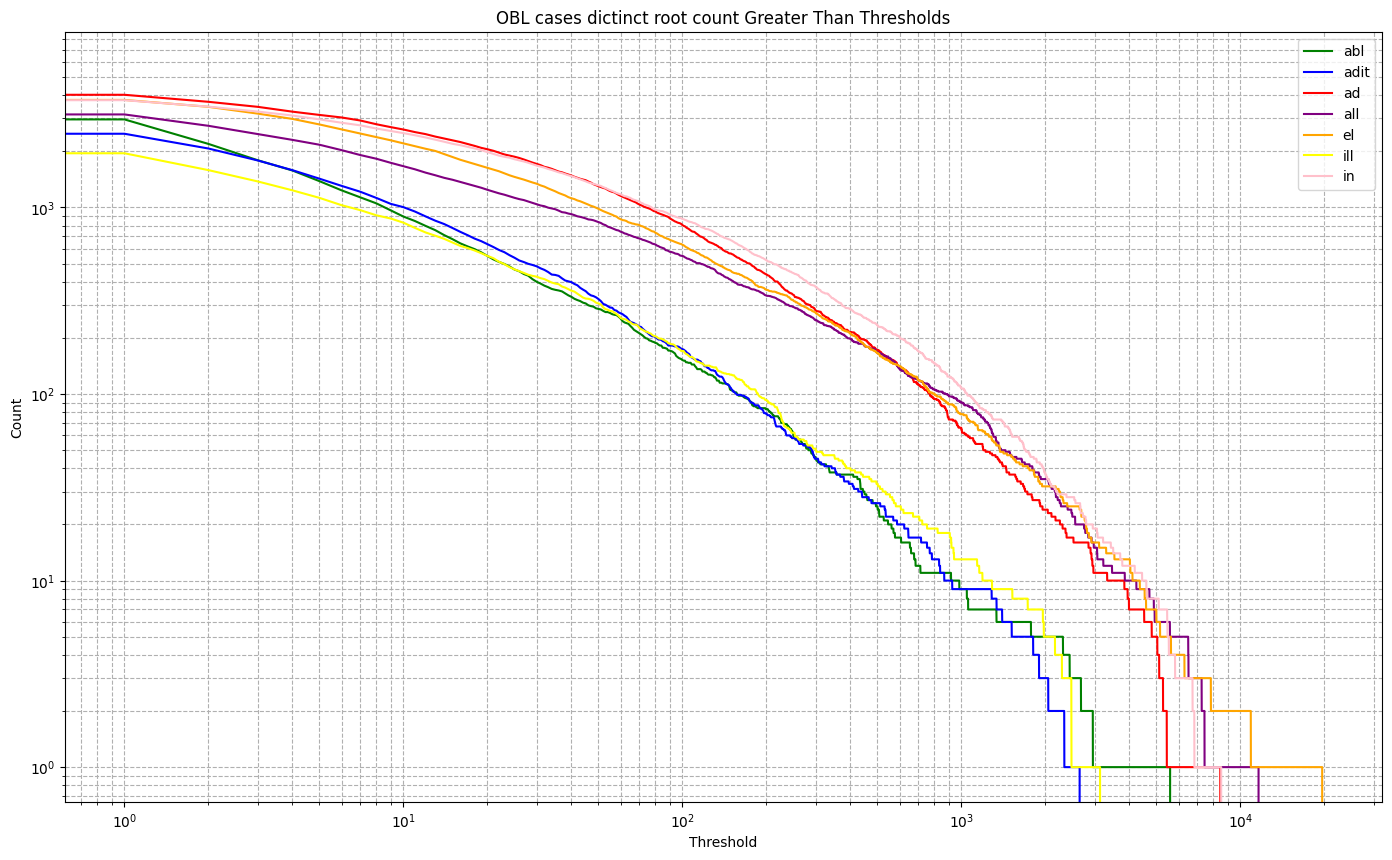

In [18]:
counts_abl = np.array(counts_abl)
counts_adit = np.array(counts_adit)
counts_ad = np.array(counts_ad)
counts_all = np.array(counts_all)
counts_el = np.array(counts_el)
counts_ill = np.array(counts_ill)
counts_in = np.array(counts_in)

# Plot the power law graph
plt.figure(figsize=(17, 10))
plt.loglog(x_abl, counts_abl, color="green")
plt.loglog(x_adit, counts_adit, color="blue")
plt.loglog(x_ad, counts_ad, color="red")
plt.loglog(x_all, counts_all, color="purple")
plt.loglog(x_el, counts_el, color="orange")
plt.loglog(x_ill, counts_ill, color="yellow")
plt.loglog(x_in, counts_in, color="pink")

plt.xlabel('Threshold')
plt.ylabel('Count')
plt.title('OBL cases dictinct root count Greater Than Thresholds')
plt.grid(True, which="both", ls="--")


plt.legend(['abl', 'adit', "ad", "all", "el", "ill", "in"]) 

plt.show()

### all cases separately

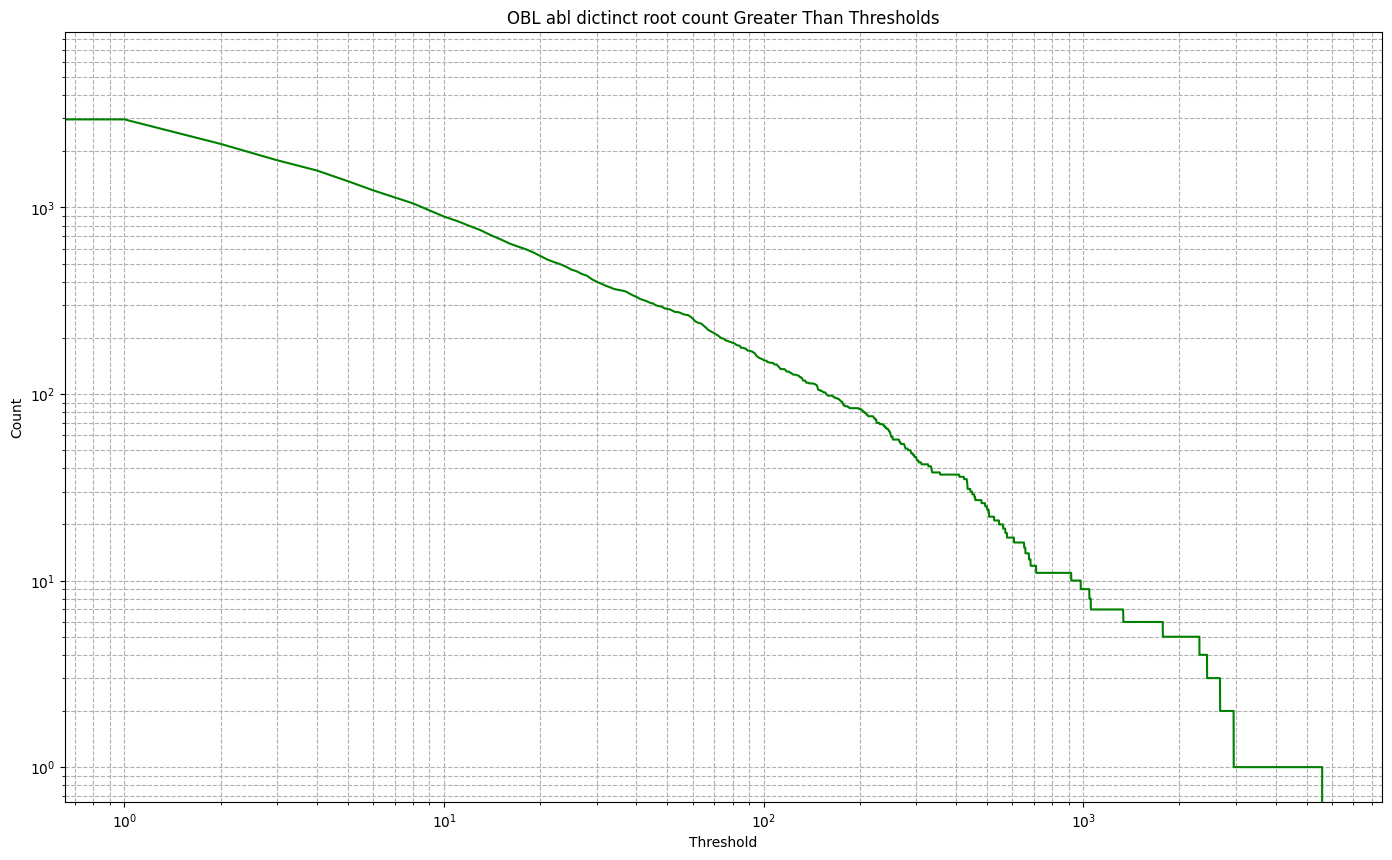

In [19]:
counts_abl = np.array(counts_abl)
# Plot the power law graph
plt.figure(figsize=(17, 10))
plt.loglog(x_abl, counts_abl, color="green")
plt.xlabel('Threshold')
plt.ylabel('Count')
plt.title('OBL abl dictinct root count Greater Than Thresholds')
plt.grid(True, which="both", ls="--")
plt.show()

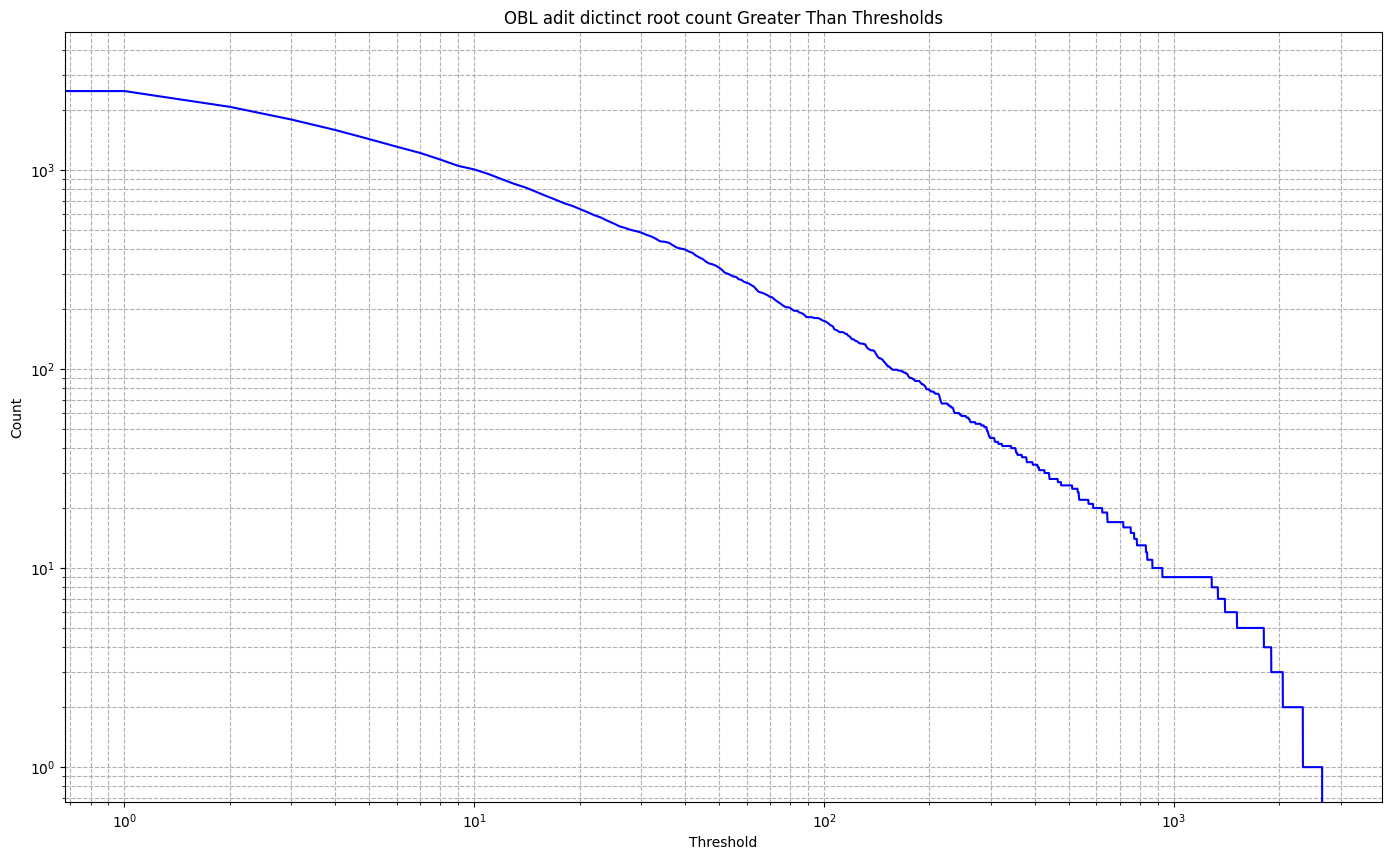

In [20]:
counts_adit = np.array(counts_adit)
# Plot the power law graph
plt.figure(figsize=(17, 10))
plt.loglog(x_adit, counts_adit, color="blue")
plt.xlabel('Threshold')
plt.ylabel('Count')
plt.title('OBL adit dictinct root count Greater Than Thresholds')
plt.grid(True, which="both", ls="--")
plt.show()

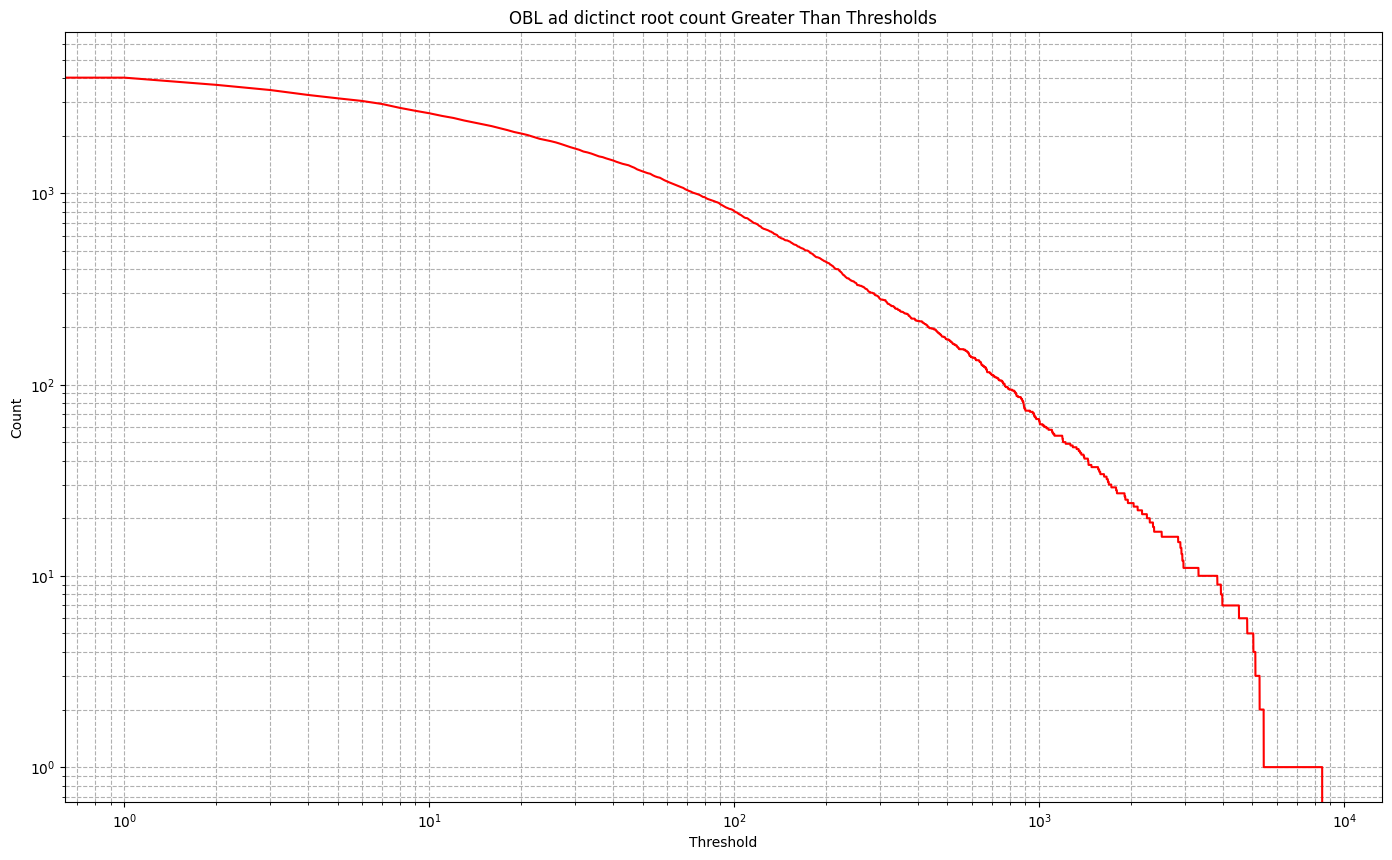

In [21]:
counts_ad = np.array(counts_ad)
# Plot the power law graph
plt.figure(figsize=(17, 10))
plt.loglog(x_ad, counts_ad, color="red")
plt.xlabel('Threshold')
plt.ylabel('Count')
plt.title('OBL ad dictinct root count Greater Than Thresholds')
plt.grid(True, which="both", ls="--")
plt.show()

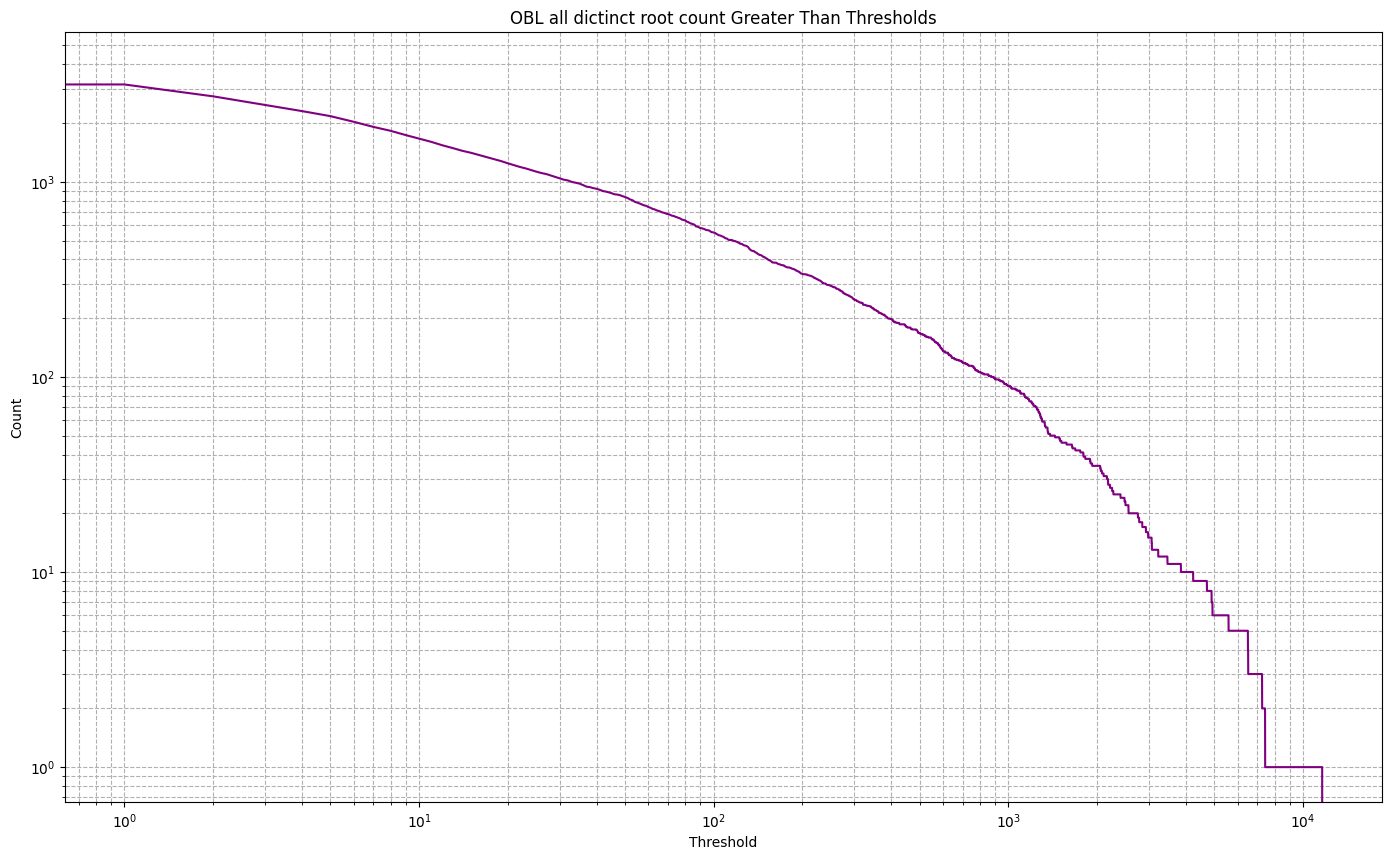

In [22]:
counts_all = np.array(counts_all)
# Plot the power law graph
plt.figure(figsize=(17, 10))
plt.loglog(x_all, counts_all, color="purple")
plt.xlabel('Threshold')
plt.ylabel('Count')
plt.title('OBL all dictinct root count Greater Than Thresholds')
plt.grid(True, which="both", ls="--")
plt.show()

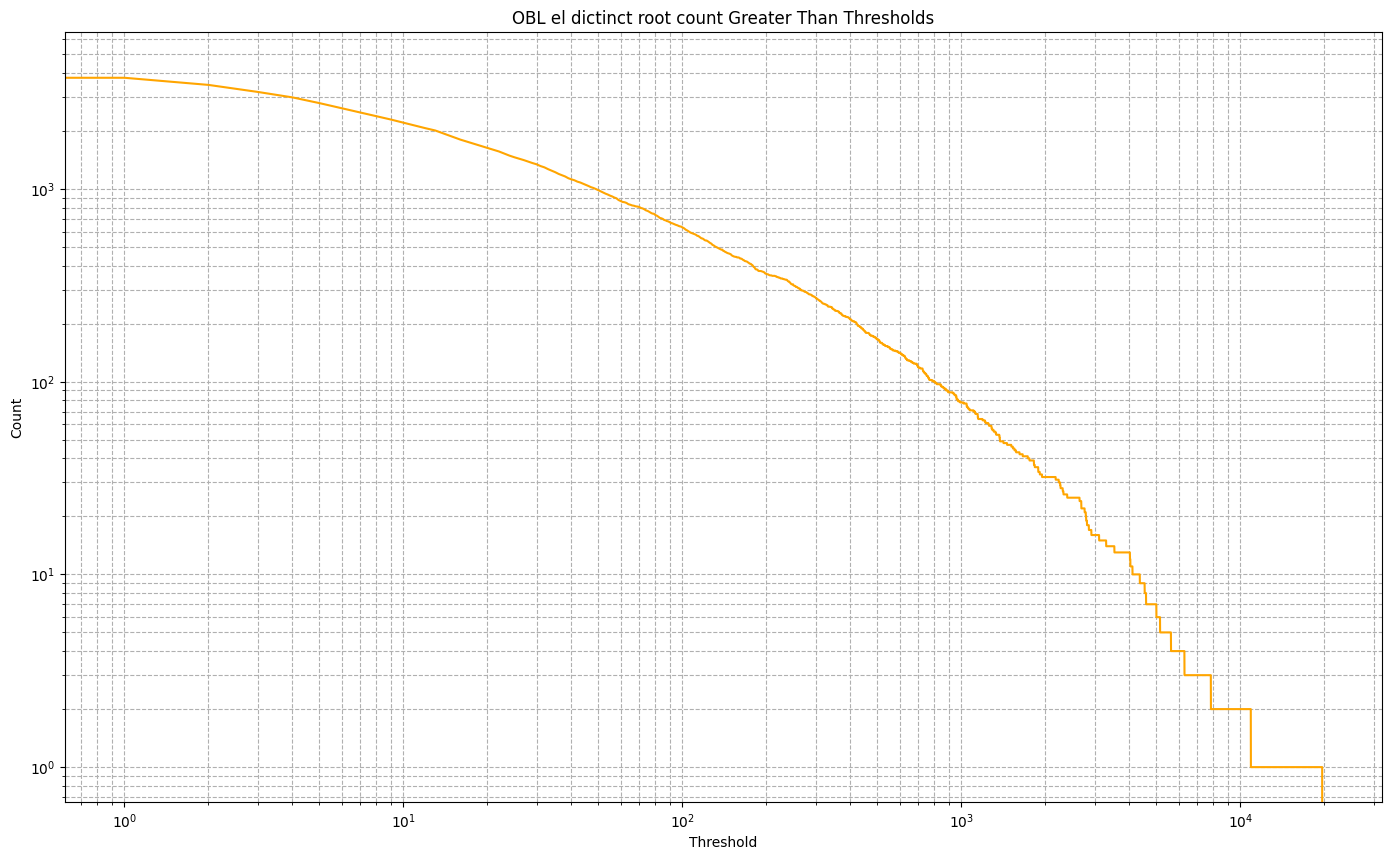

In [23]:
counts_el = np.array(counts_el)
# Plot the power law graph
plt.figure(figsize=(17, 10))
plt.loglog(x_el, counts_el, color="orange")
plt.xlabel('Threshold')
plt.ylabel('Count')
plt.title('OBL el dictinct root count Greater Than Thresholds')
plt.grid(True, which="both", ls="--")
plt.show()

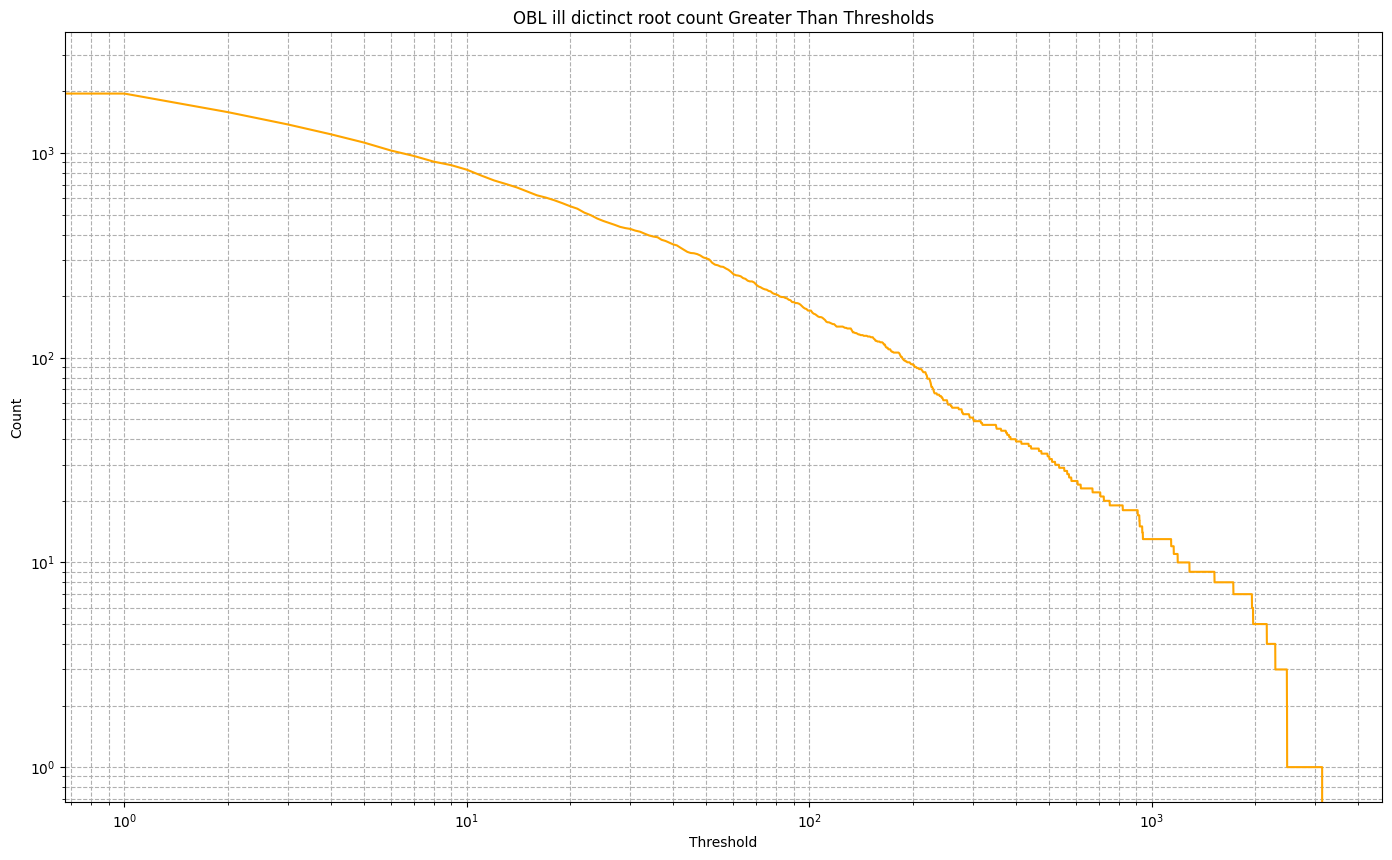

In [24]:
counts_ill = np.array(counts_ill)
# Plot the power law graph
plt.figure(figsize=(17, 10))
plt.loglog(x_ill, counts_ill, color="orange")
plt.xlabel('Threshold')
plt.ylabel('Count')
plt.title('OBL ill dictinct root count Greater Than Thresholds')
plt.grid(True, which="both", ls="--")
plt.show()

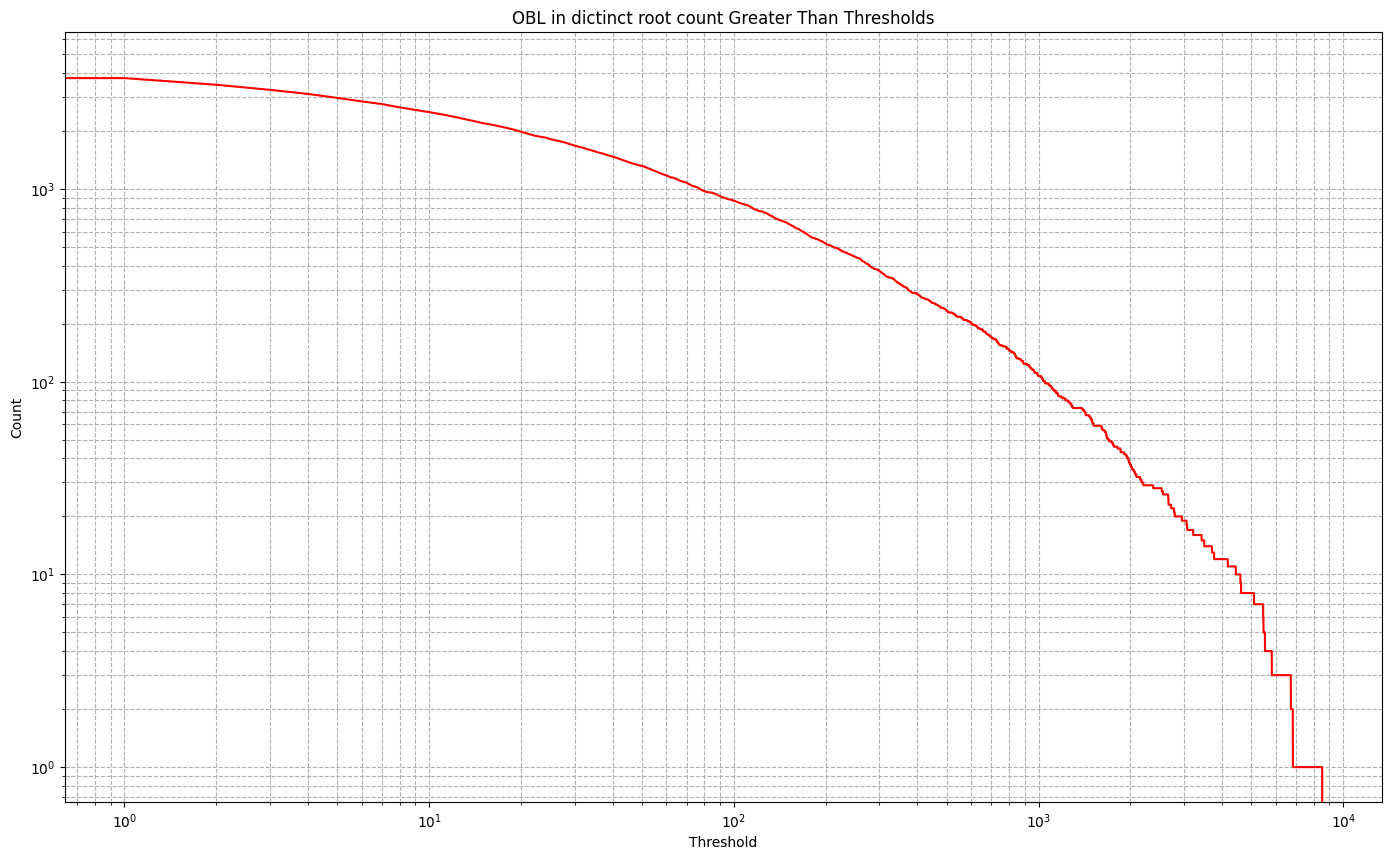

In [25]:
counts_in = np.array(counts_in)
# Plot the power law graph
plt.figure(figsize=(17, 10))
plt.loglog(x_in, counts_in, color="red")
plt.xlabel('Threshold')
plt.ylabel('Count')
plt.title('OBL in dictinct root count Greater Than Thresholds')
plt.grid(True, which="both", ls="--")
plt.show()

### something???

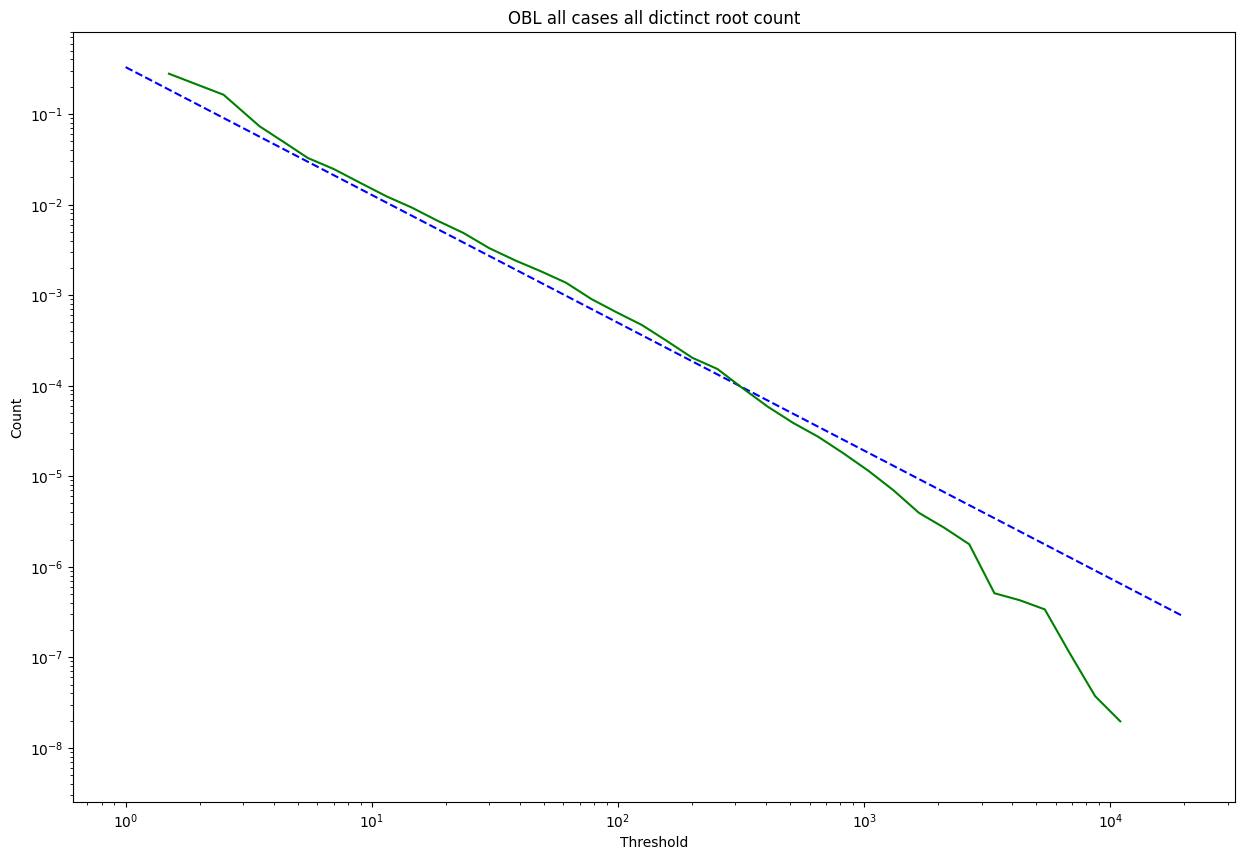

In [26]:
plt.figure(figsize=(15, 10))
fit = pwl.Fit(np.array(all_values)+1,xmin=1,discrete=True)
fit.power_law.plot_pdf( color= 'b',linestyle='--',label='fit ccdf')
fit.plot_pdf( color= 'g')
plt.xlabel('Threshold')
plt.ylabel('Count')
plt.title('OBL all cases all dictinct root count')
plt.show()
#print('alpha= ',fit.power_law.alpha,'  sigma= ',fit.power_law.sigma)

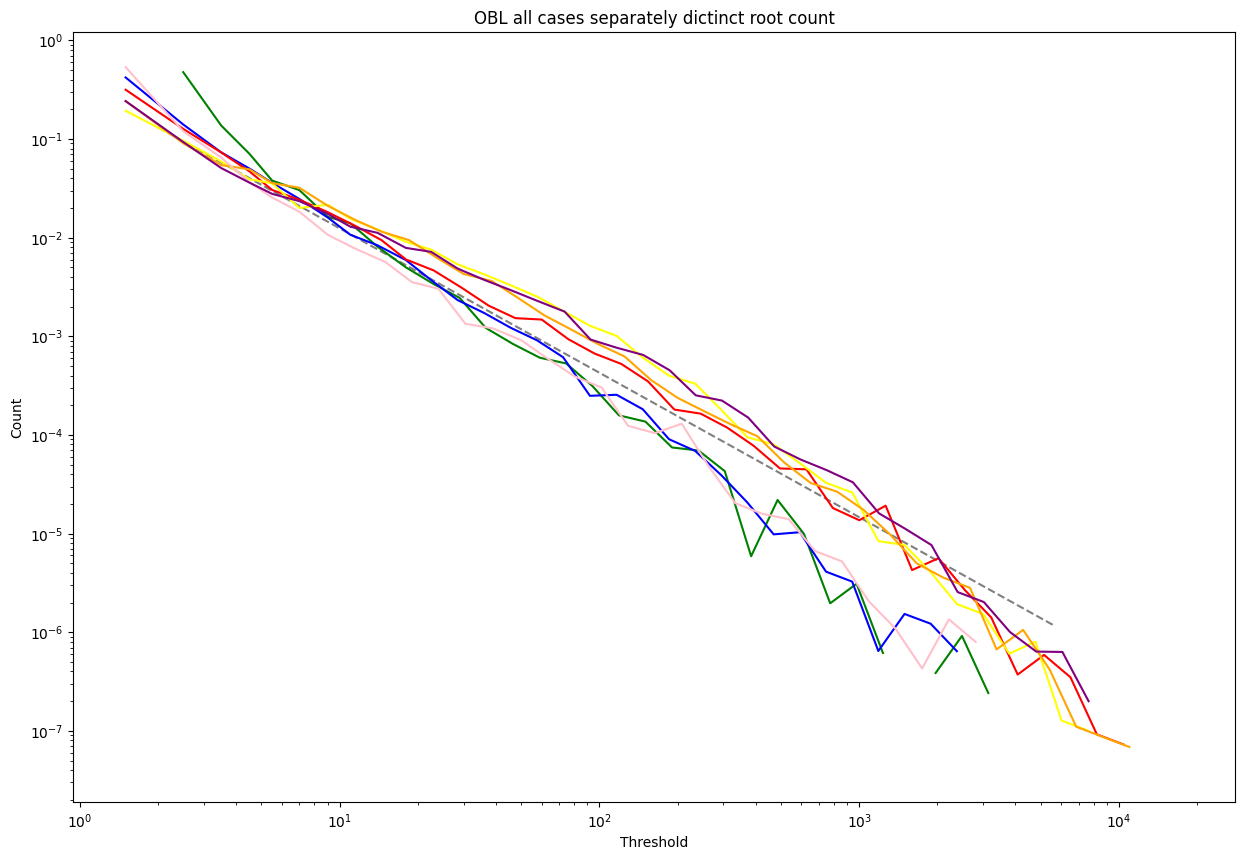

In [27]:
plt.figure(figsize=(15, 10))

fit1 = pwl.Fit(np.array(list(source["abl_cnt"]))+1,xmin=1,discrete=True)
fit2 = pwl.Fit(np.array(list(source["adit_cnt"]))+1,xmin=1,discrete=True)
fit3 = pwl.Fit(np.array(list(source["all_cnt"]))+1,xmin=1,discrete=True)
fit4 = pwl.Fit(np.array(list(source["ad_cnt"]))+1,xmin=1,discrete=True)
fit5 = pwl.Fit(np.array(list(source["el_cnt"]))+1,xmin=1,discrete=True)
fit6 = pwl.Fit(np.array(list(source["ill_cnt"]))+1,xmin=1,discrete=True)
fit7 = pwl.Fit(np.array(list(source["in_cnt"]))+1,xmin=1,discrete=True)
fit1.power_law.plot_pdf( color= 'grey',linestyle='--',label='fit ccdf')
fit1.plot_pdf( color= 'green',label='abl')
fit2.plot_pdf( color= 'blue')
fit3.plot_pdf( color= 'red')
fit4.plot_pdf( color= 'yellow')
fit5.plot_pdf( color= 'orange')
fit6.plot_pdf( color= 'pink')
fit7.plot_pdf( color= 'purple')

plt.xlabel('Threshold')
plt.ylabel('Count')
plt.title('OBL all cases separately dictinct root count')
plt.show()

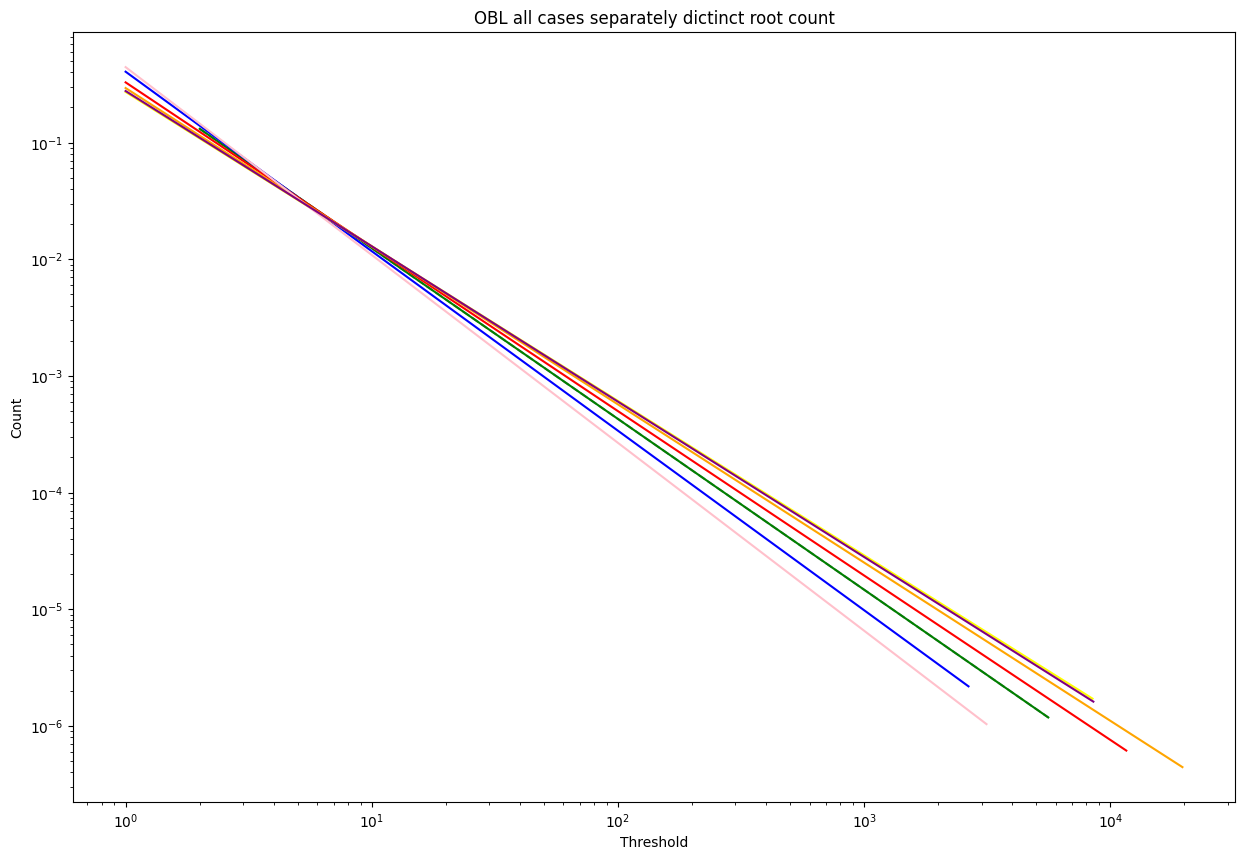

In [28]:
plt.figure(figsize=(15, 10))

fit1 = pwl.Fit(np.array(list(source["abl_cnt"]))+1,xmin=1,discrete=True)
fit2 = pwl.Fit(np.array(list(source["adit_cnt"]))+1,xmin=1,discrete=True)
fit3 = pwl.Fit(np.array(list(source["all_cnt"]))+1,xmin=1,discrete=True)
fit4 = pwl.Fit(np.array(list(source["ad_cnt"]))+1,xmin=1,discrete=True)
fit5 = pwl.Fit(np.array(list(source["el_cnt"]))+1,xmin=1,discrete=True)
fit6 = pwl.Fit(np.array(list(source["ill_cnt"]))+1,xmin=1,discrete=True)
fit7 = pwl.Fit(np.array(list(source["in_cnt"]))+1,xmin=1,discrete=True)
fit1.power_law.plot_pdf( color= 'grey',linestyle='--',label='fit ccdf')
fit1.power_law.plot_pdf( color= 'green',label='abl')
fit2.power_law.plot_pdf( color= 'blue')
fit3.power_law.plot_pdf( color= 'red')
fit4.power_law.plot_pdf( color= 'yellow')
fit5.power_law.plot_pdf( color= 'orange')
fit6.power_law.plot_pdf( color= 'pink')
fit7.power_law.plot_pdf( color= 'purple')

plt.xlabel('Threshold')
plt.ylabel('Count')
plt.title('OBL all cases separately dictinct root count')
plt.show()

# ggplot - mingi probleem sellega

In [117]:
from plotnine import ggplot, aes, geom_line

In [121]:

#ggplot(df1) + aes(x="cell_value", y="count")

# AttributeError: 'YAxis' object has no attribute 'get_tick_params'

In [ ]:
# saab teha ka tabeliga kus distinct root asemel on count(root)
# transactions_verbs_obl_kohakaandes_root_counts_matches.csv

## 2. tabel

### iga verb+obl+kohakääne jaoks count elus ja count koht, count kokku

## base tabel kus on verb, kääne, elus_cnt, koht_cnt, distinct root count  

In [29]:
query = """

SELECT *
from transactions_verbs_obl_kohakaandes_eluskoht_root_counts_distinct_base_wcomps_v1 
--transactions_verbs_obl_kohakaandes_eluskoht_root_counts_matches
"""

source2 = pd.read_sql_query(query, con)
source2

,verb,verb_compound,kaane,elus_cnt,koht_cnt,root_cnt
0,saama,,el,1274,402,19632
1,andma,,all,1601,250,11612
2,rääkima,,el,802,202,10891
3,saama,,in,134,306,8532
4,tulema,,ad,1134,166,8468
...,...,...,...,...,...,...
74715,šveitsima,,el,0,0,1
74716,švipsima,,ad,0,0,1
74717,žestikuleerima,,ad,0,1,1
74718,žisraelima,,ad,0,0,1


# PILDID 2

- elus vs koht jaotus
- x: elusad
- y: elutud
    - igast reast elus ja koht annavad punkti
    - punkti suurus/tumedus viitab sellele kui palju see punkt katab (root_cnt)
    
-> näitab kuidas msutrid paiknevad ja kas on nt 3:1 või 2:1 jaotus

- kui kasutada absoluutväärtust siis kõrgemal olevad on kindlamad ja madalamal olevatest teame vähem


- teine variant:
    - elus cnt ja koht cnt jagada läbi rootcnt
    - siis kõik punktid paiknevad 0 ja 100 vahel
    

kui ei taha kasutada punkti värvi/suurust siis tabelile filter nt lävend rootcnt >=10, >=100 jne

In [30]:
# mida suurem root_cnt seda suurem ringike võiks olla 

areadict = {}

root_cnts = sorted(list(set(list(source2["root_cnt"])))) # 1-21K

# raadius min 1 ja max 15
# 1-10 : 
# 10-100: 
# 100-500: 
# 500-1000: 
# 1000-2000: 
# 2000-5000: 
# 5000-10000: 
# 10000-20000:

for cnt in root_cnts:
    if cnt <10: areadict[cnt] = 1
    elif cnt >=10 and cnt < 100: areadict[cnt] = 5
    elif cnt >=100 and cnt < 500: areadict[cnt] = 10
    elif cnt >=500 and cnt < 1000: areadict[cnt] = 30
    elif cnt >=1000 and cnt < 2000: areadict[cnt] = 50
    elif cnt >=2000 and cnt < 5000: areadict[cnt] = 80
    elif cnt >=5000 and cnt < 10000: areadict[cnt] = 100
    elif cnt >=10000 and cnt < 15000: areadict[cnt] = 300
    elif cnt >=15000 and cnt < 20000: areadict[cnt] = 500
    elif cnt >=20000: areadict[cnt] = 700


## absoluutväärtustega pilt

### 1) nii nagu on ilma piiranguteta

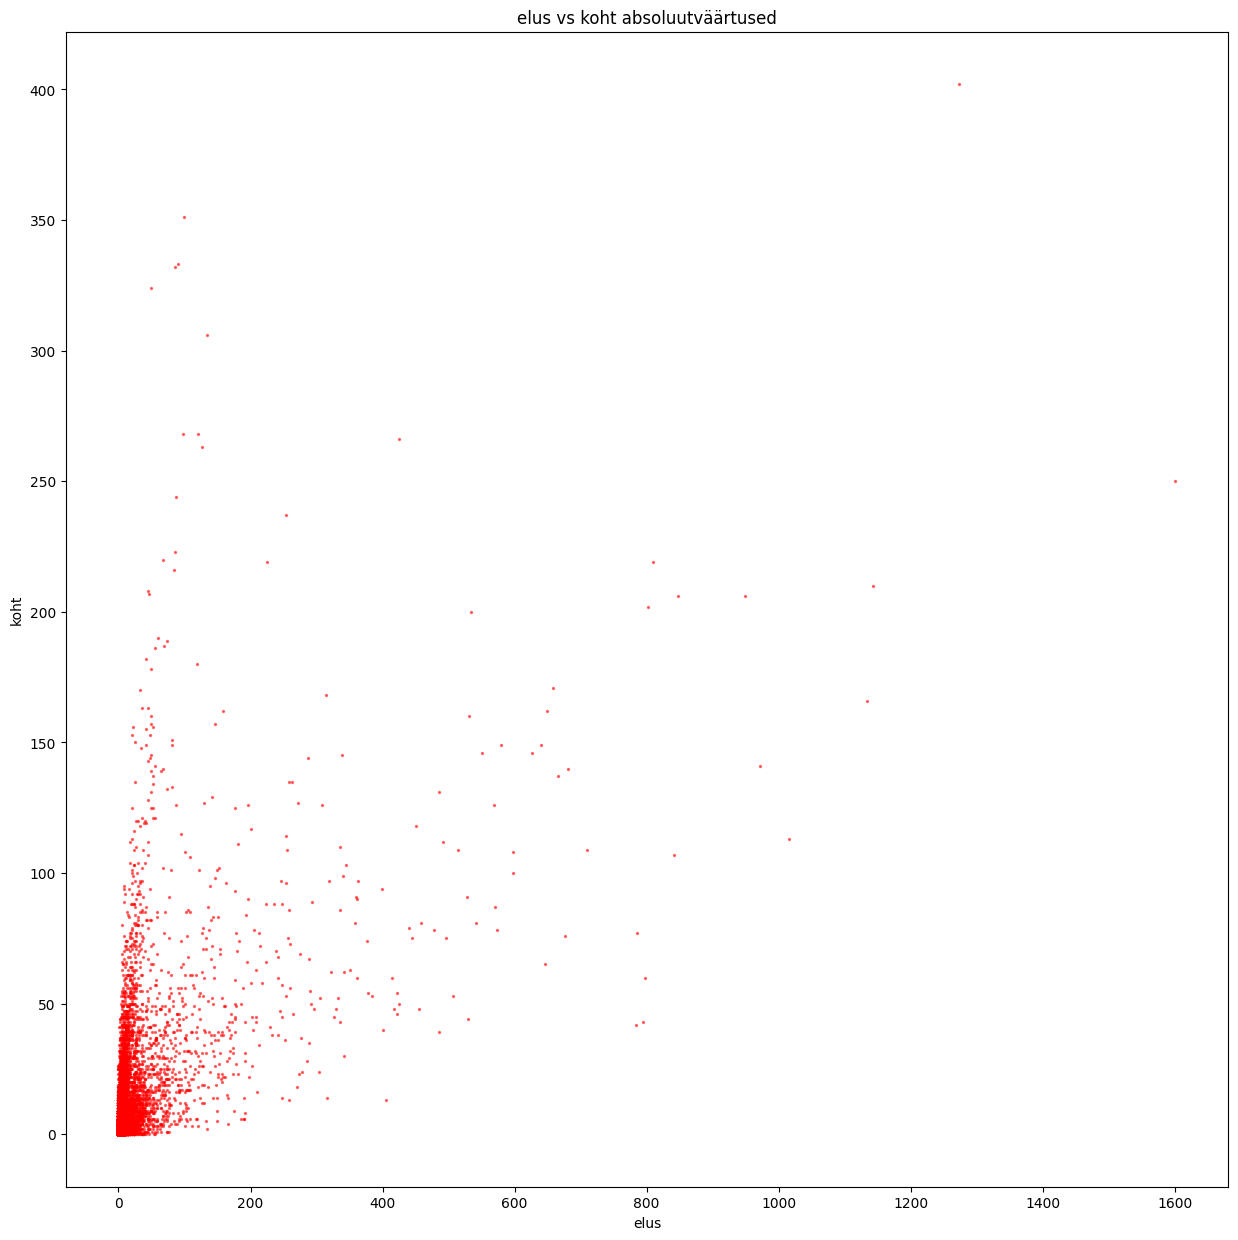

In [31]:
plt.figure(figsize=(15, 15))
x = list(source2["elus_cnt"])
y = list(source2["koht_cnt"])

N = len(source2)
colors = np.random.rand(N)

area = 2  # 0 to 15 point radii

plt.scatter(x, y, s=area, c='r', alpha=0.5)


plt.title("elus vs koht absoluutväärtused")
plt.ylabel("koht")
plt.xlabel("elus")


plt.show()

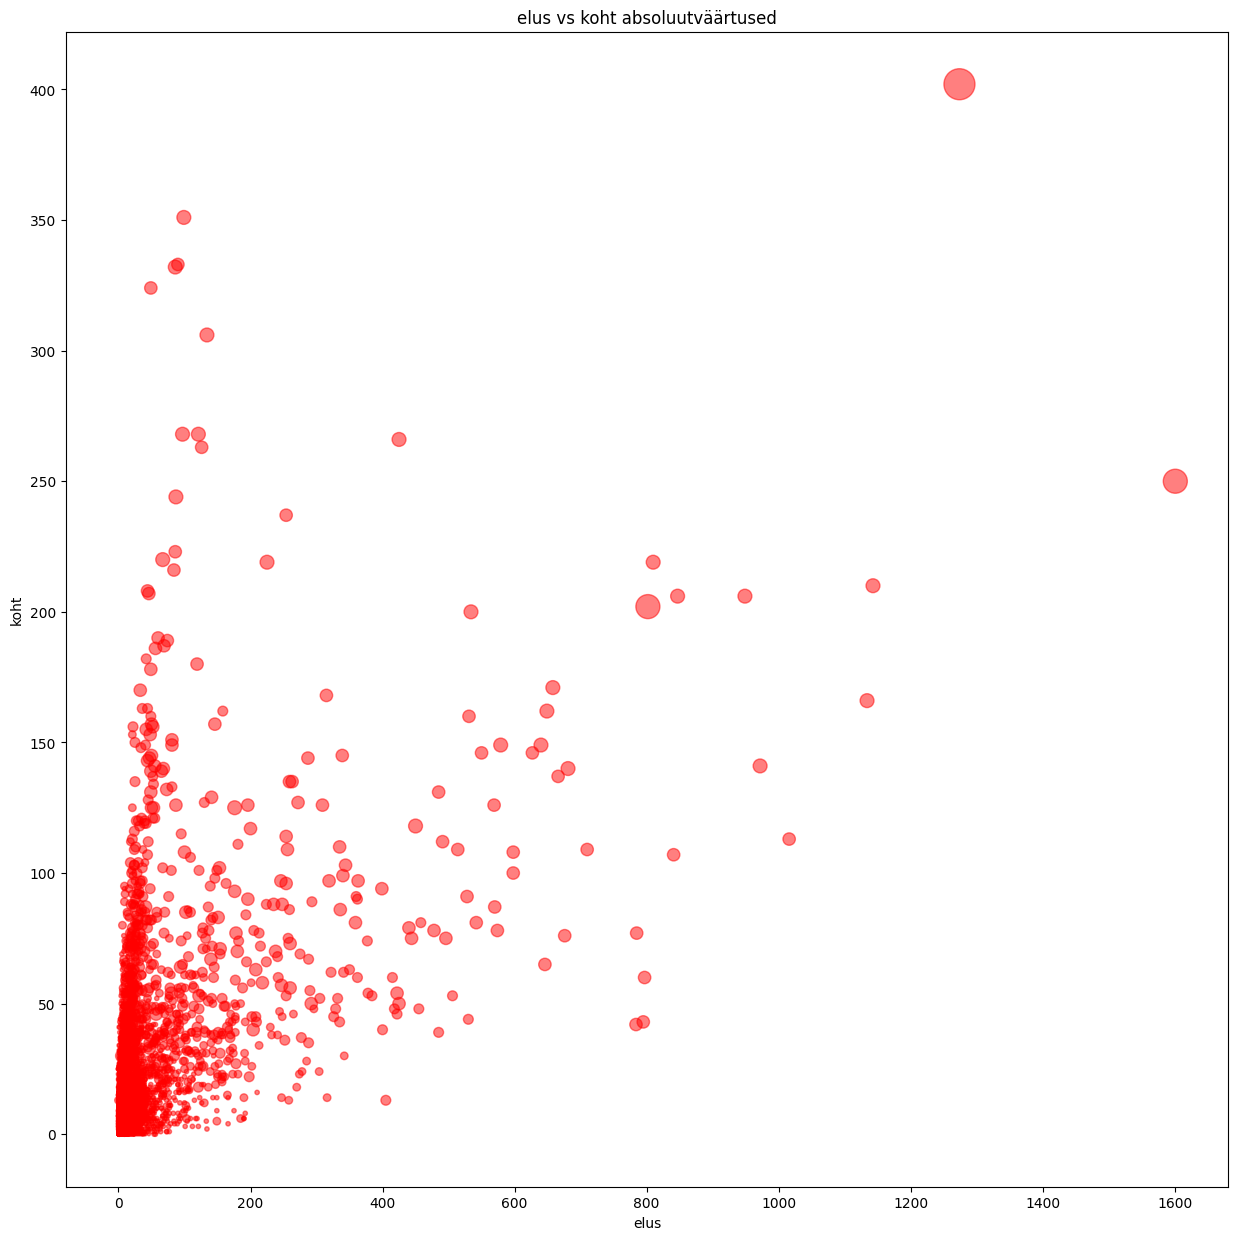

In [32]:
plt.figure(figsize=(15, 15))
x = list(source2["elus_cnt"])
y = list(source2["koht_cnt"])

N = len(source2)
colors = np.random.rand(N)

area = [areadict[cnt] for cnt in list(source2["root_cnt"])]

plt.scatter(x, y, s=area, c='r', alpha=0.5)


plt.title("elus vs koht absoluutväärtused")
plt.ylabel("koht")
plt.xlabel("elus")


plt.show()

### 2) filrtid

### filter 1: root_cnt >=10

In [33]:
source3 = source2[source2["root_cnt"]>=10]

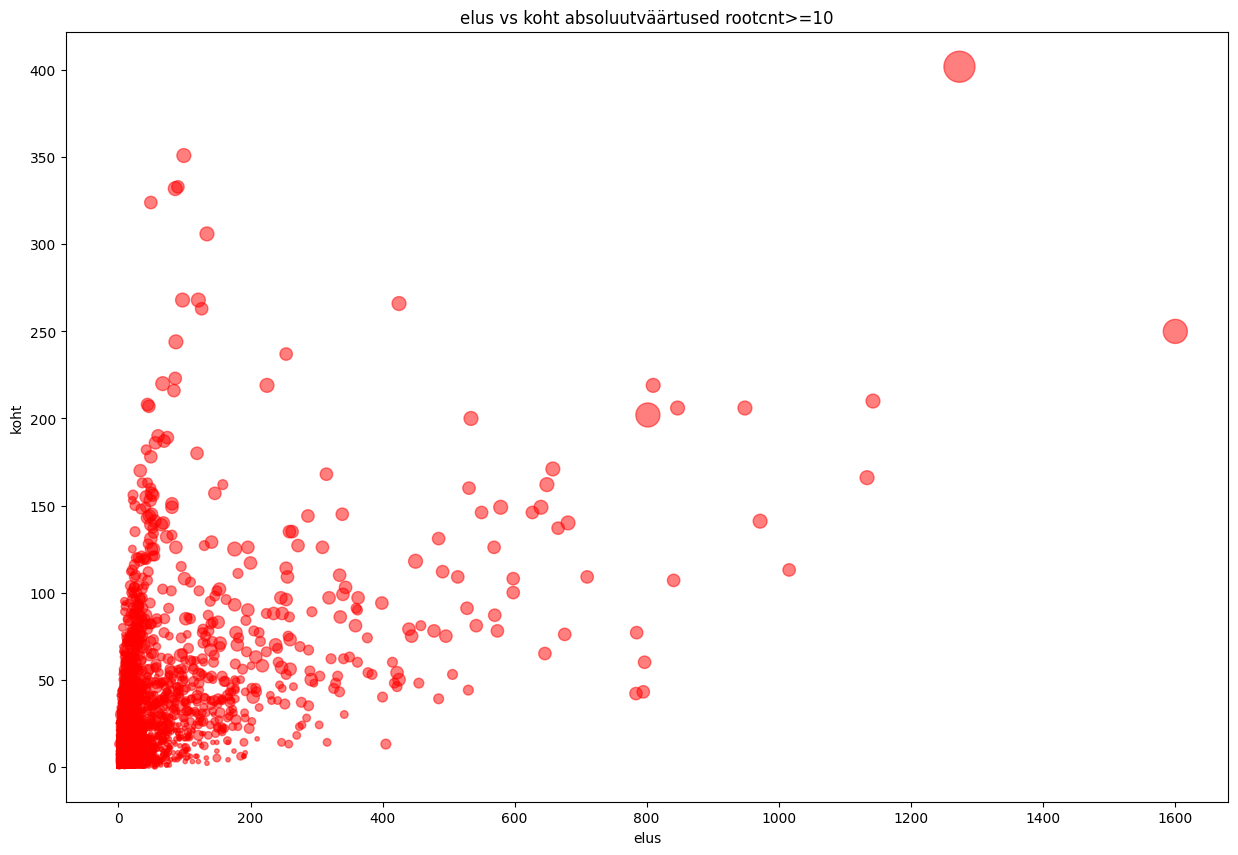

In [34]:
plt.figure(figsize=(15, 10))
x = list(source3["elus_cnt"])
y = list(source3["koht_cnt"])

#N = len(source3)
#colors = np.random.rand(N)

area = [areadict[cnt] for cnt in list(source3["root_cnt"])]

plt.scatter(x, y, s=area, c='r', alpha=0.5)


plt.title("elus vs koht absoluutväärtused rootcnt>=10")
plt.ylabel("koht")
plt.xlabel("elus")


plt.show()

### filter 1: root_cnt >=100

In [35]:
source3 = source2[source2["root_cnt"]>=100]

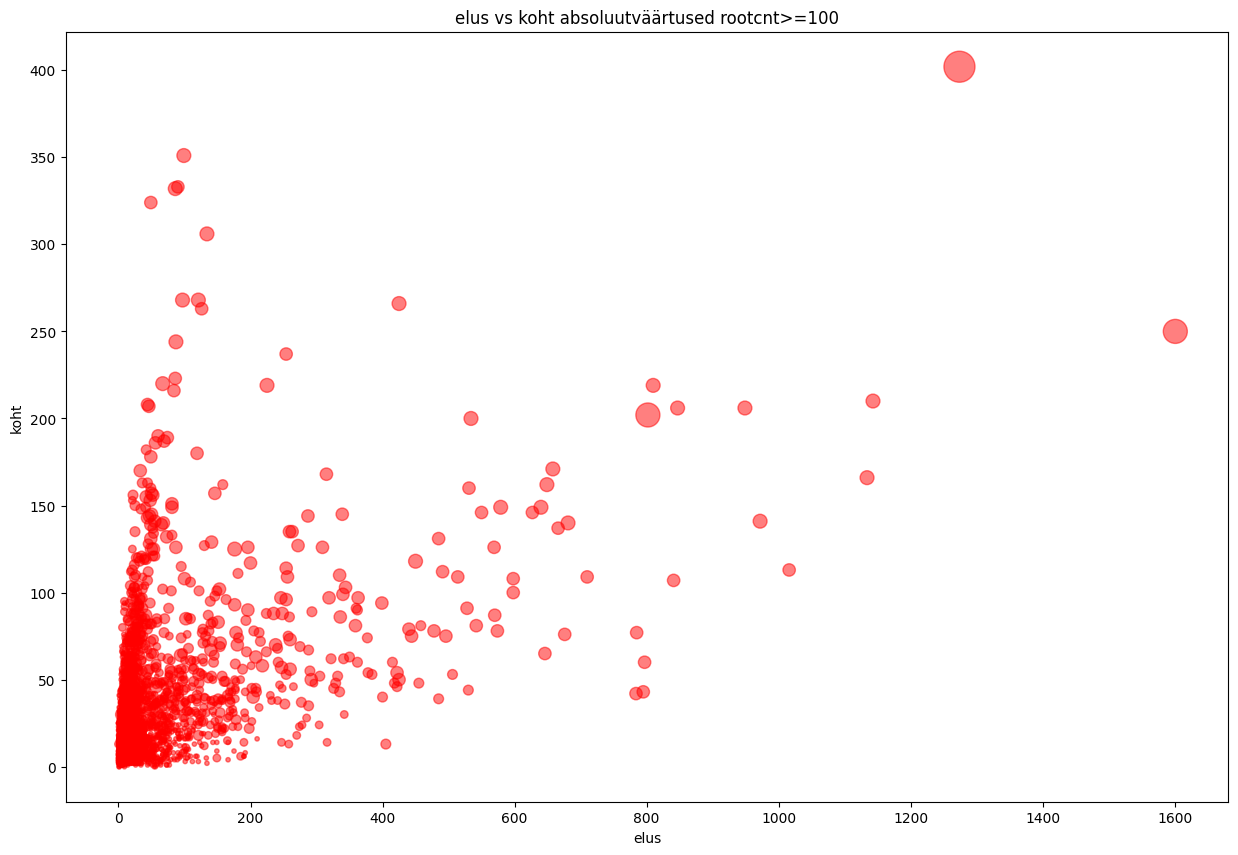

In [36]:
plt.figure(figsize=(15, 10))
x = list(source3["elus_cnt"])
y = list(source3["koht_cnt"])

#N = len(source3)
#colors = np.random.rand(N)

area = [areadict[cnt] for cnt in list(source3["root_cnt"])]

plt.scatter(x, y, s=area, c='r', alpha=0.5)


plt.title("elus vs koht absoluutväärtused rootcnt>=100")
plt.ylabel("koht")
plt.xlabel("elus")


plt.show()

### filter 1: root_cnt >=1000

In [37]:
source3 = source2[source2["root_cnt"]>=1000]

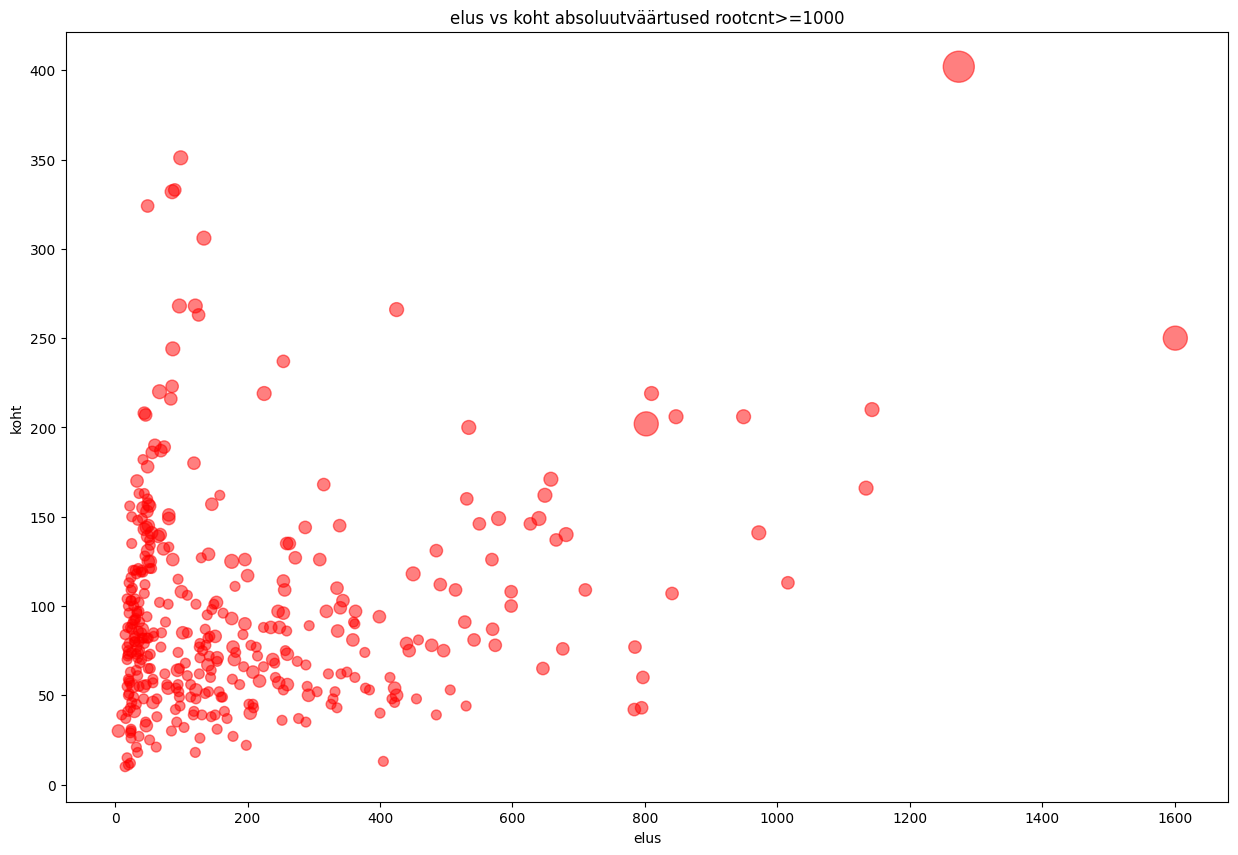

In [38]:
plt.figure(figsize=(15, 10))
x = list(source3["elus_cnt"])
y = list(source3["koht_cnt"])

#N = len(source3)
#colors = np.random.rand(N)

area = [areadict[cnt] for cnt in list(source3["root_cnt"])]

plt.scatter(x, y, s=area, c='r', alpha=0.5)


plt.title("elus vs koht absoluutväärtused rootcnt>=1000")
plt.ylabel("koht")
plt.xlabel("elus")


plt.show()

### filter 1: root_cnt <=1000

In [39]:
source3 = source2[source2["root_cnt"]<=1000]

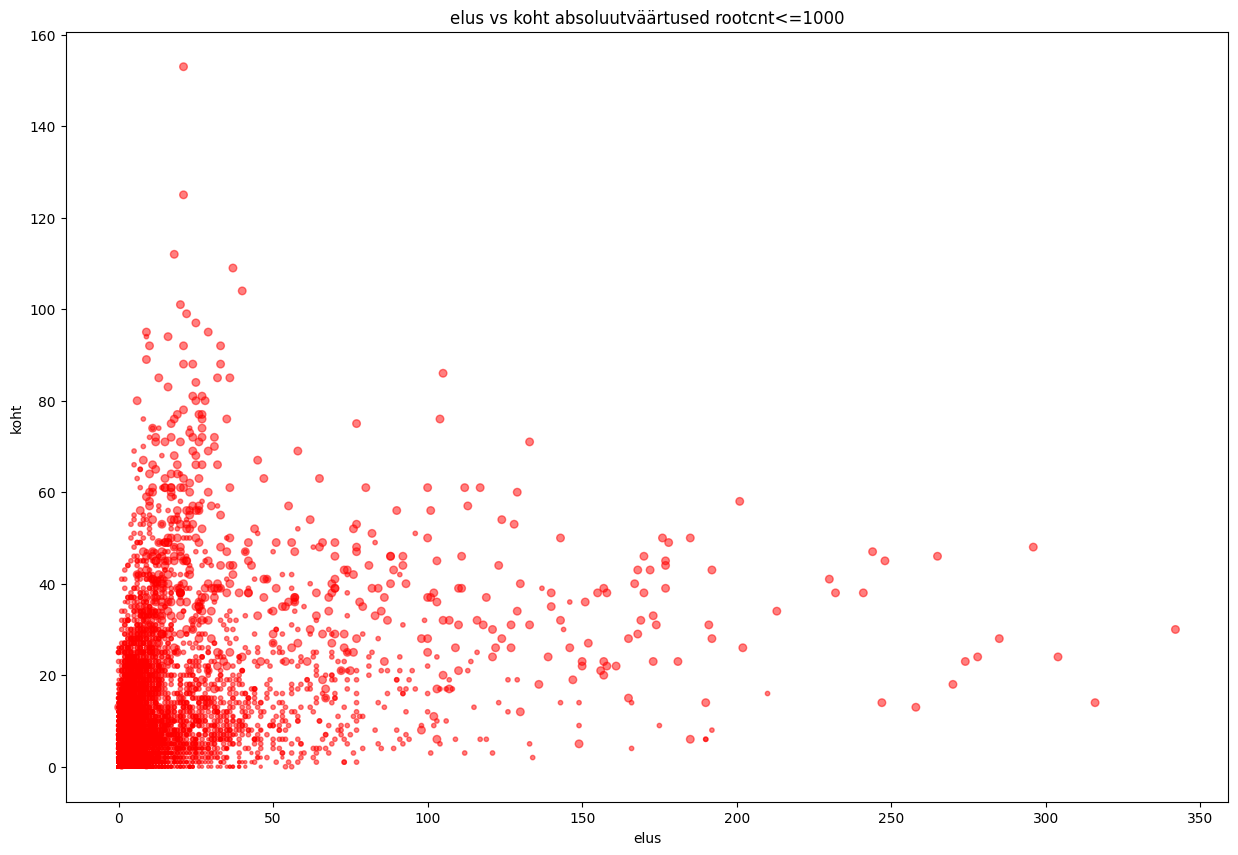

In [40]:
plt.figure(figsize=(15, 10))
x = list(source3["elus_cnt"])
y = list(source3["koht_cnt"])

#N = len(source3)
#colors = np.random.rand(N)

area = [areadict[cnt] for cnt in list(source3["root_cnt"])]

plt.scatter(x, y, s=area, c='r', alpha=0.5)


plt.title("elus vs koht absoluutväärtused rootcnt<=1000")
plt.ylabel("koht")
plt.xlabel("elus")


plt.show()

### filter 1: root_cnt <=500

In [41]:
source3 = source2[source2["root_cnt"]<=500]

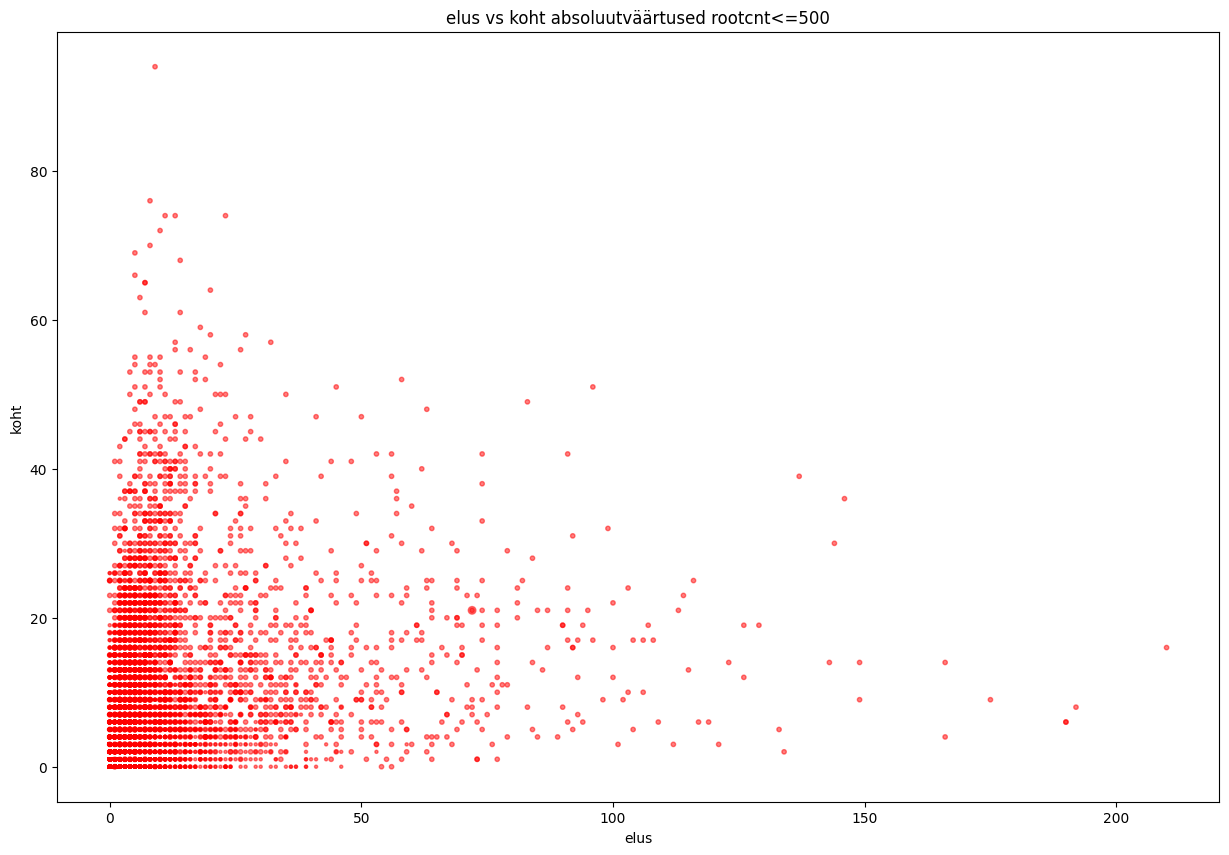

In [42]:
plt.figure(figsize=(15, 10))
x = list(source3["elus_cnt"])
y = list(source3["koht_cnt"])

#N = len(source3)
#colors = np.random.rand(N)

area = [areadict[cnt] for cnt in list(source3["root_cnt"])]

plt.scatter(x, y, s=area, c='r', alpha=0.5)


plt.title("elus vs koht absoluutväärtused rootcnt<=500")
plt.ylabel("koht")
plt.xlabel("elus")


plt.show()

### filter 1: root_cnt >=5000

In [43]:
source3 = source2[source2["root_cnt"]>=5000]

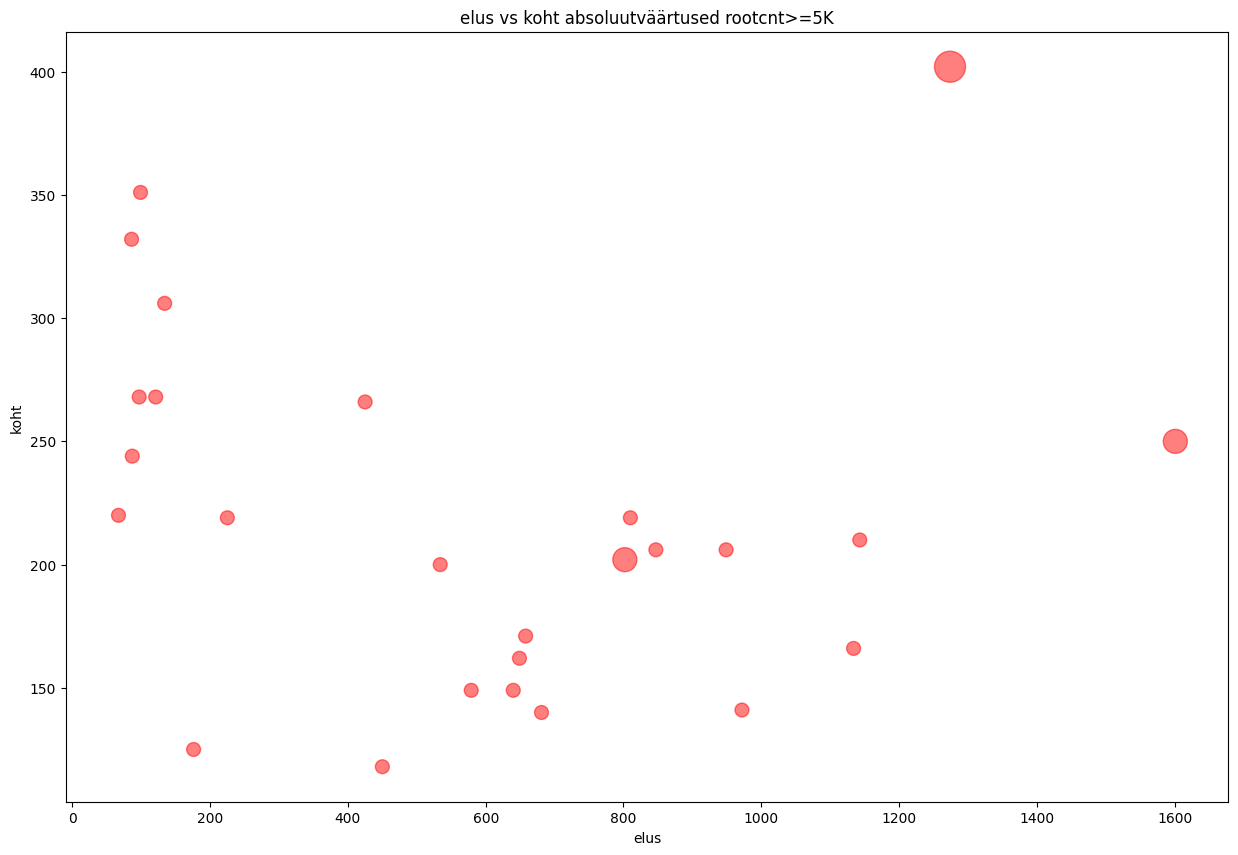

In [44]:
plt.figure(figsize=(15, 10))
x = list(source3["elus_cnt"])
y = list(source3["koht_cnt"])

#N = len(source3)
#colors = np.random.rand(N)

area = [areadict[cnt] for cnt in list(source3["root_cnt"])]

plt.scatter(x, y, s=area, c='r', alpha=0.5)


plt.title("elus vs koht absoluutväärtused rootcnt>=5K")
plt.ylabel("koht")
plt.xlabel("elus")


plt.show()

### filter 2: root_cnt >=10 & koht <10000 & elus < 10000

In [45]:
source3 = source2[(source2["root_cnt"]>=10) & (source2["koht_cnt"]<10000) & (source2["elus_cnt"]<10000)]

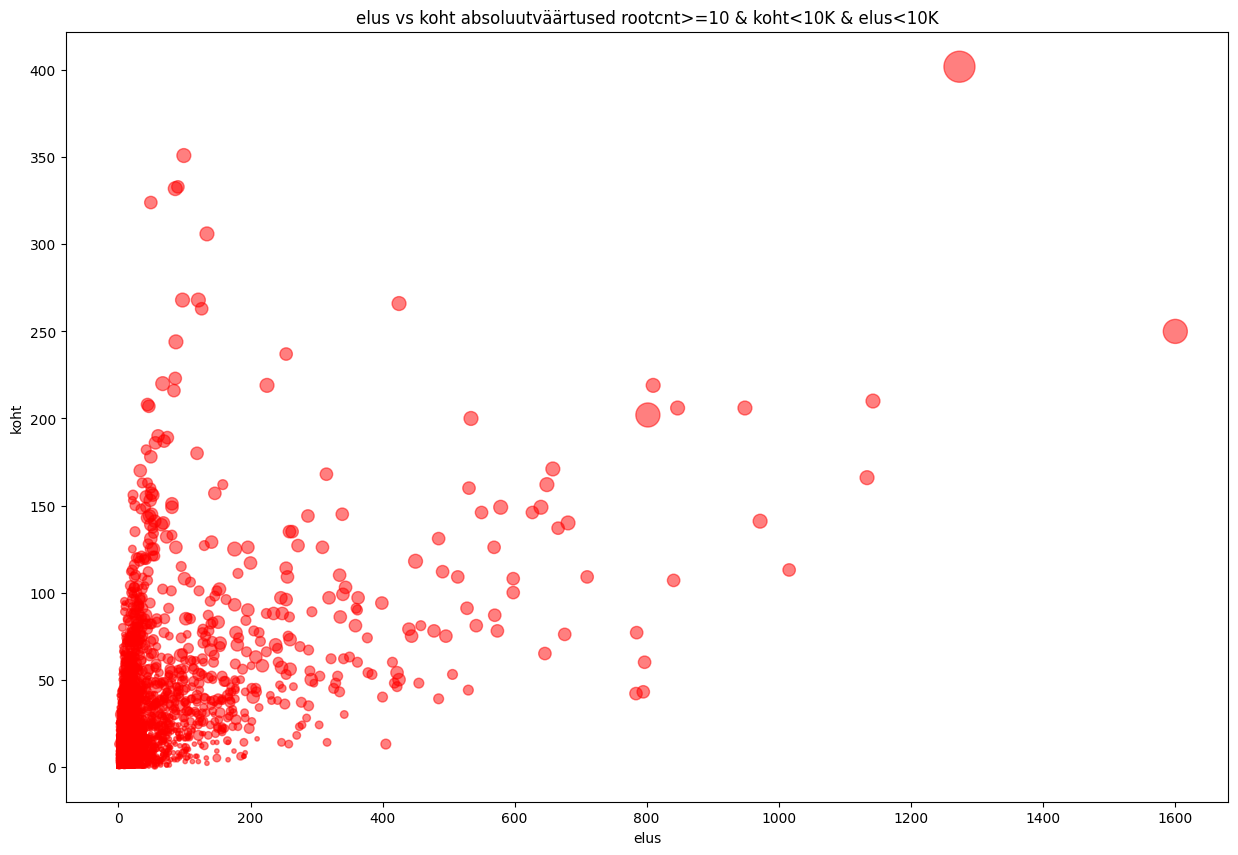

In [46]:
plt.figure(figsize=(15, 10))
x = list(source3["elus_cnt"])
y = list(source3["koht_cnt"])

#N = len(source3)
#colors = np.random.rand(N)

area = [areadict[cnt] for cnt in list(source3["root_cnt"])]

plt.scatter(x, y, s=area, c='r', alpha=0.5)


plt.title("elus vs koht absoluutväärtused rootcnt>=10 & koht<10K & elus<10K")
plt.ylabel("koht")
plt.xlabel("elus")


plt.show()

### filter 2: root_cnt >=1000 & koht <10000 & elus < 10000

In [47]:
source3 = source2[(source2["root_cnt"]>=1000) & (source2["koht_cnt"]<10000) & (source2["elus_cnt"]<10000)]

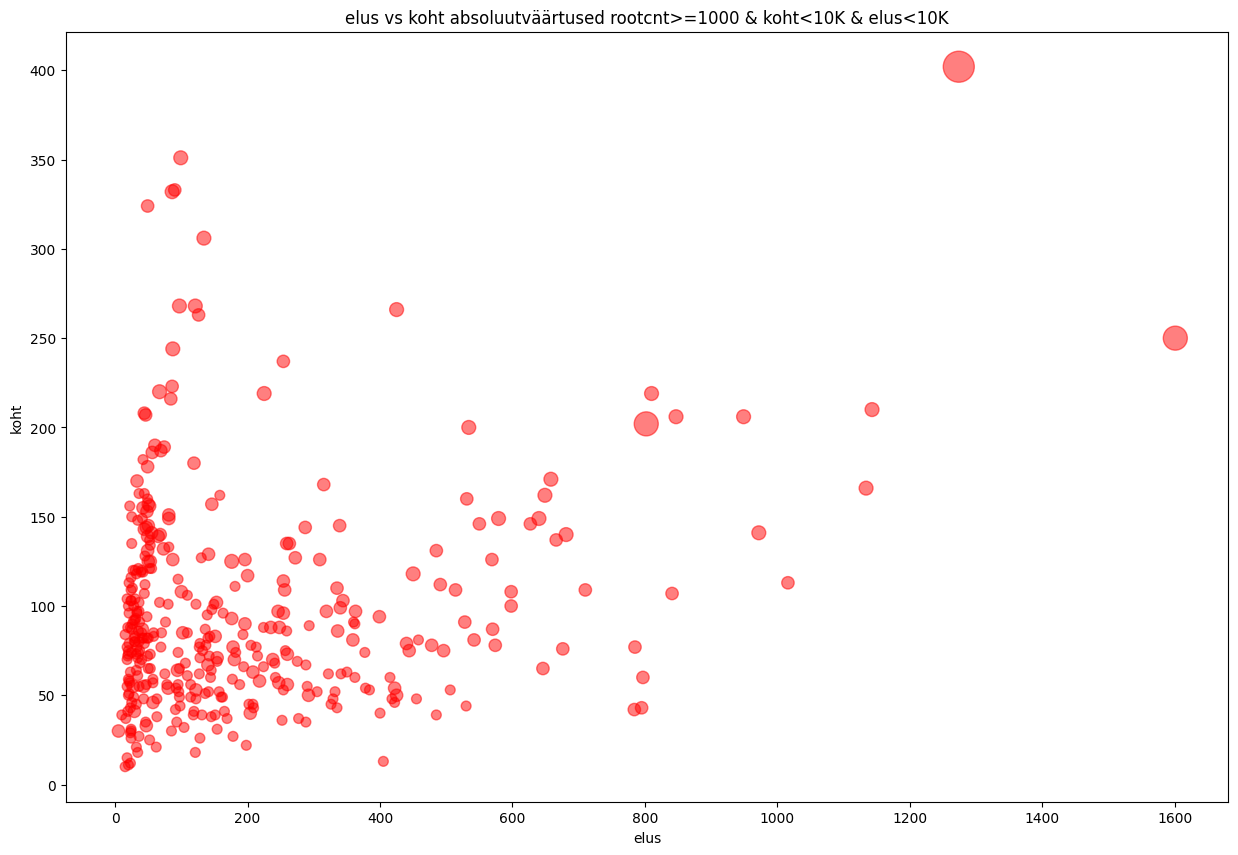

In [48]:
plt.figure(figsize=(15, 10))
x = list(source3["elus_cnt"])
y = list(source3["koht_cnt"])

#N = len(source3)
#colors = np.random.rand(N)

area = [areadict[cnt] for cnt in list(source3["root_cnt"])]

plt.scatter(x, y, s=area, c='r', alpha=0.5)


plt.title("elus vs koht absoluutväärtused rootcnt>=1000 & koht<10K & elus<10K")
plt.ylabel("koht")
plt.xlabel("elus")


plt.show()

## normaliseeritud väärtustega pilt

In [49]:
elusad = []
kohad = []
roots = []

for i in range(len(source2)):
    roots.append(source2.iloc[i]["root_cnt"])
    kohad.append(source2.iloc[i]["koht_cnt"]/source2.iloc[i]["root_cnt"])
    elusad.append(source2.iloc[i]["elus_cnt"]/source2.iloc[i]["root_cnt"])

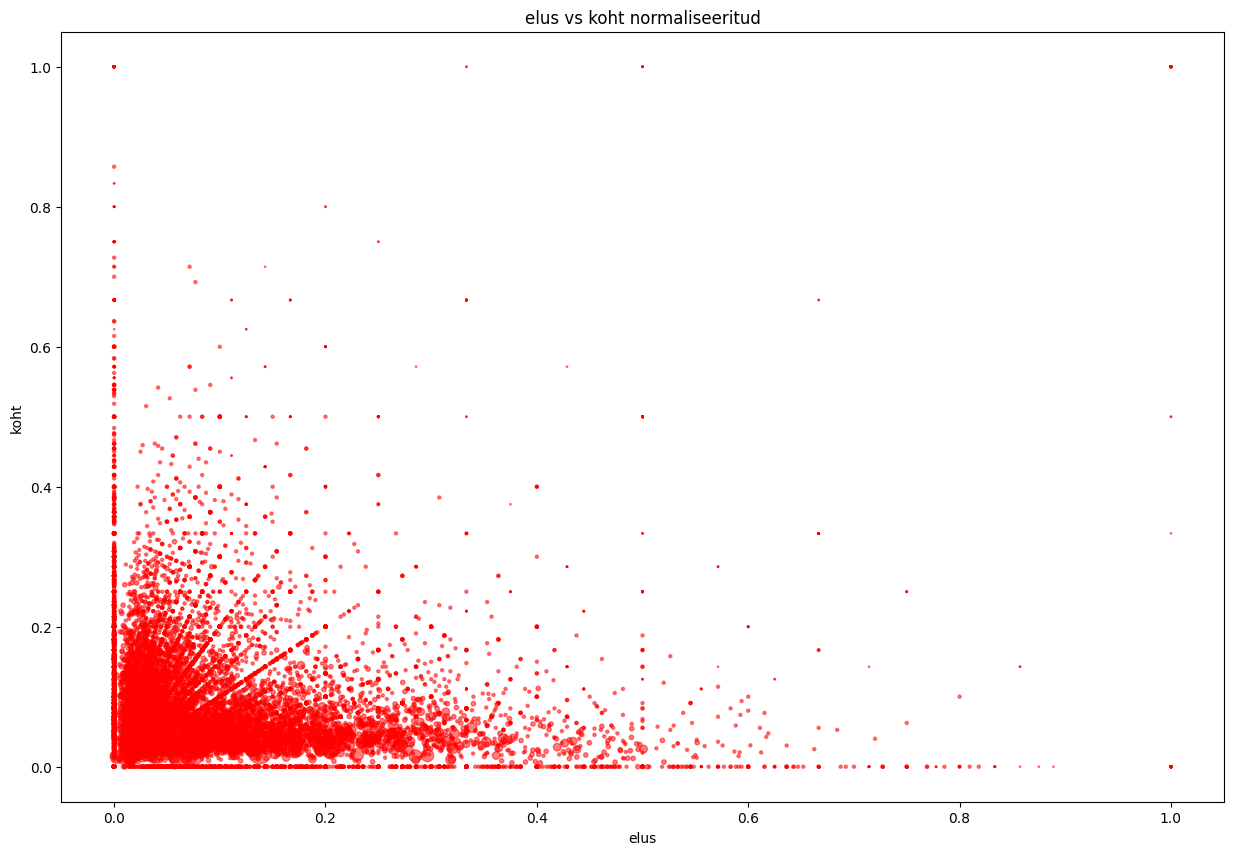

In [50]:
plt.figure(figsize=(15, 10))
x = elusad
y = kohad

#N = len(source3)
#colors = np.random.rand(N)

area = [areadict[cnt] for cnt in roots]

plt.scatter(x, y, s=area, c='r', alpha=0.5)


plt.title("elus vs koht normaliseeritud")
plt.ylabel("koht")
plt.xlabel("elus")


plt.show()

### filter 1: root_cnt >=10

In [51]:
elusad = []
kohad = []
roots = []

for i in range(len(source2)):
    if source2.iloc[i]["root_cnt"]>=10:
        roots.append(source2.iloc[i]["root_cnt"])
        kohad.append(source2.iloc[i]["koht_cnt"]/source2.iloc[i]["root_cnt"])
        elusad.append(source2.iloc[i]["elus_cnt"]/source2.iloc[i]["root_cnt"])

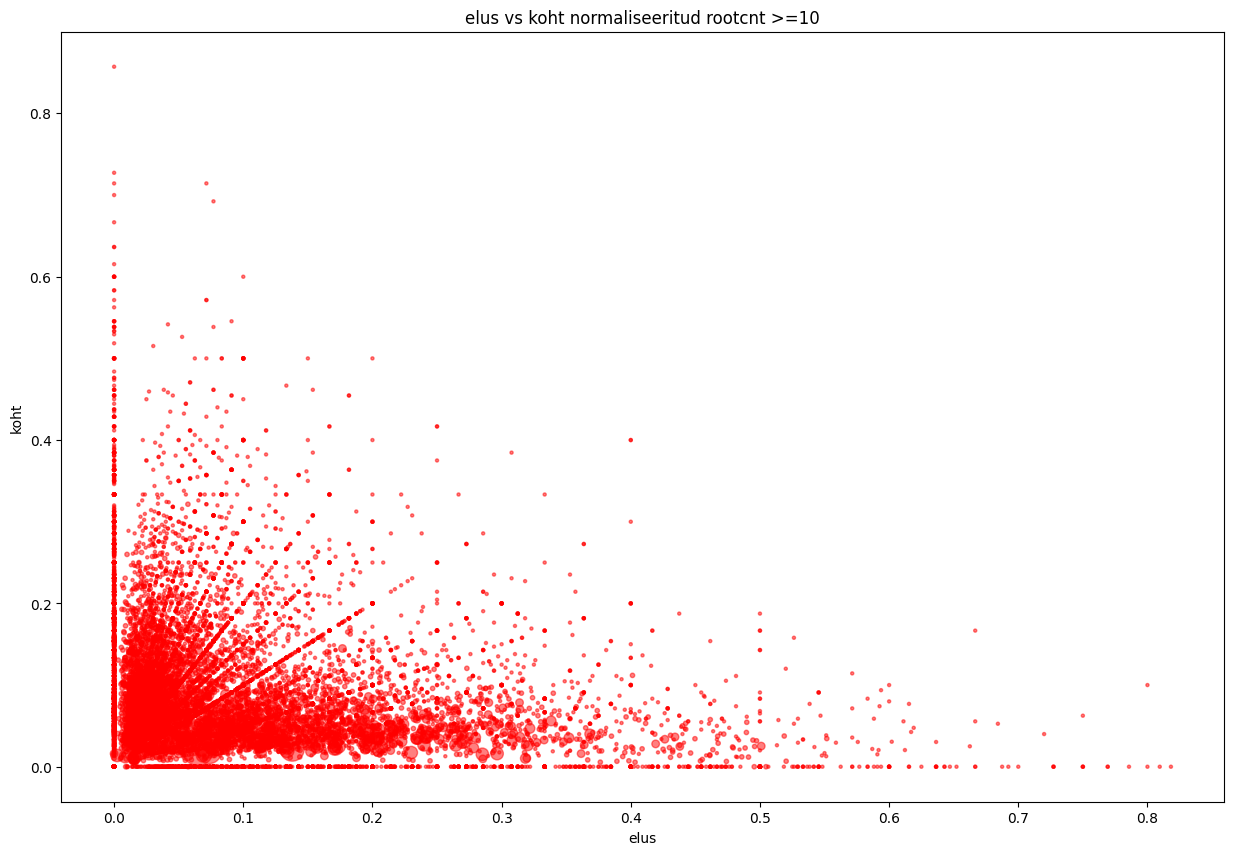

In [52]:
plt.figure(figsize=(15, 10))
x = elusad
y = kohad

#N = len(source3)
#colors = np.random.rand(N)

area = [areadict[cnt] for cnt in roots]

plt.scatter(x, y, s=area, c='r', alpha=0.5)


plt.title("elus vs koht normaliseeritud rootcnt >=10")
plt.ylabel("koht")
plt.xlabel("elus")


plt.show()

### filter 1: root_cnt >=100

In [53]:
elusad = []
kohad = []
roots = []

for i in range(len(source2)):
    if source2.iloc[i]["root_cnt"]>=100:
        roots.append(source2.iloc[i]["root_cnt"])
        kohad.append(source2.iloc[i]["koht_cnt"]/source2.iloc[i]["root_cnt"])
        elusad.append(source2.iloc[i]["elus_cnt"]/source2.iloc[i]["root_cnt"])

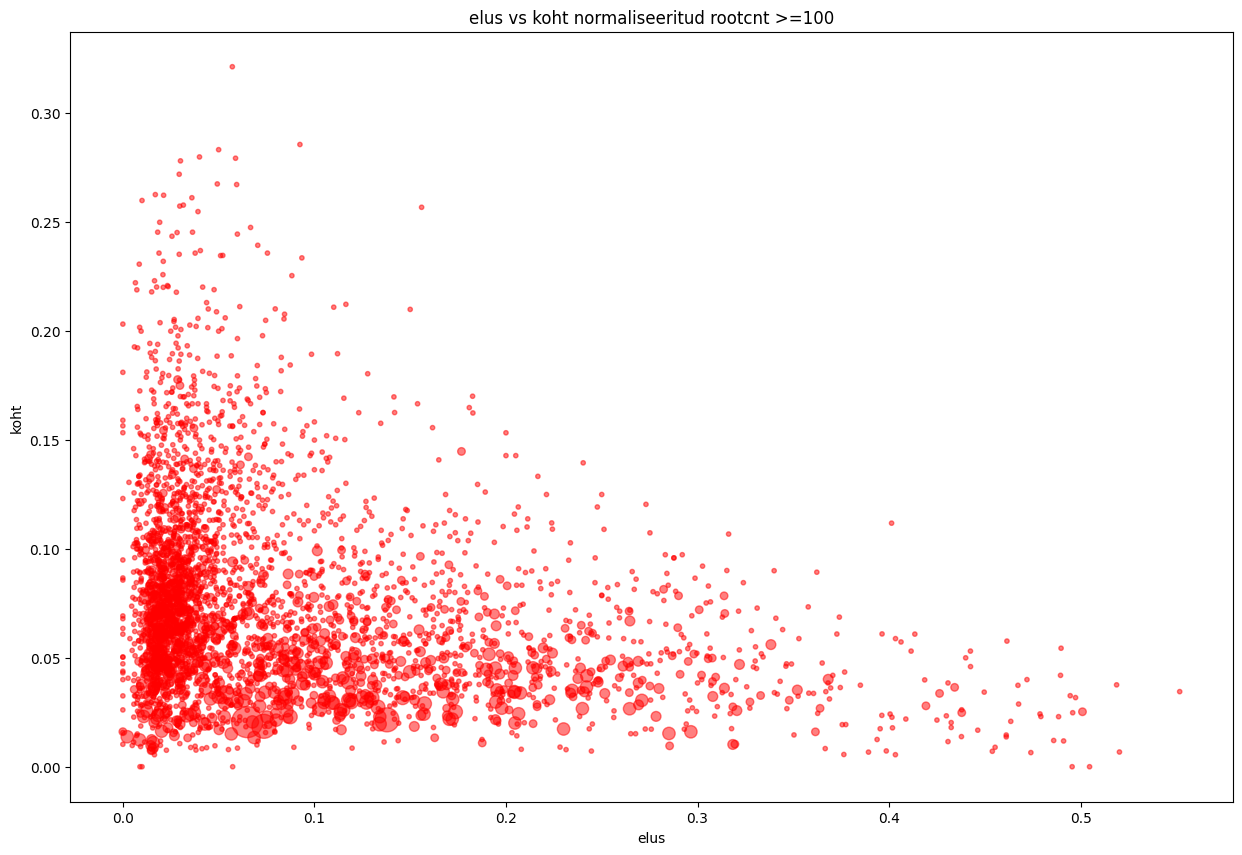

In [54]:
plt.figure(figsize=(15, 10))
x = elusad
y = kohad

#N = len(source3)
#colors = np.random.rand(N)

area = [areadict[cnt] for cnt in roots]

plt.scatter(x, y, s=area, c='r', alpha=0.5)


plt.title("elus vs koht normaliseeritud rootcnt >=100")
plt.ylabel("koht")
plt.xlabel("elus")


plt.show()

### filter 1: root_cnt >=1000

In [55]:
elusad = []
kohad = []
roots = []

for i in range(len(source2)):
    if source2.iloc[i]["root_cnt"]>=1000:
        roots.append(source2.iloc[i]["root_cnt"])
        kohad.append(source2.iloc[i]["koht_cnt"]/source2.iloc[i]["root_cnt"])
        elusad.append(source2.iloc[i]["elus_cnt"]/source2.iloc[i]["root_cnt"])

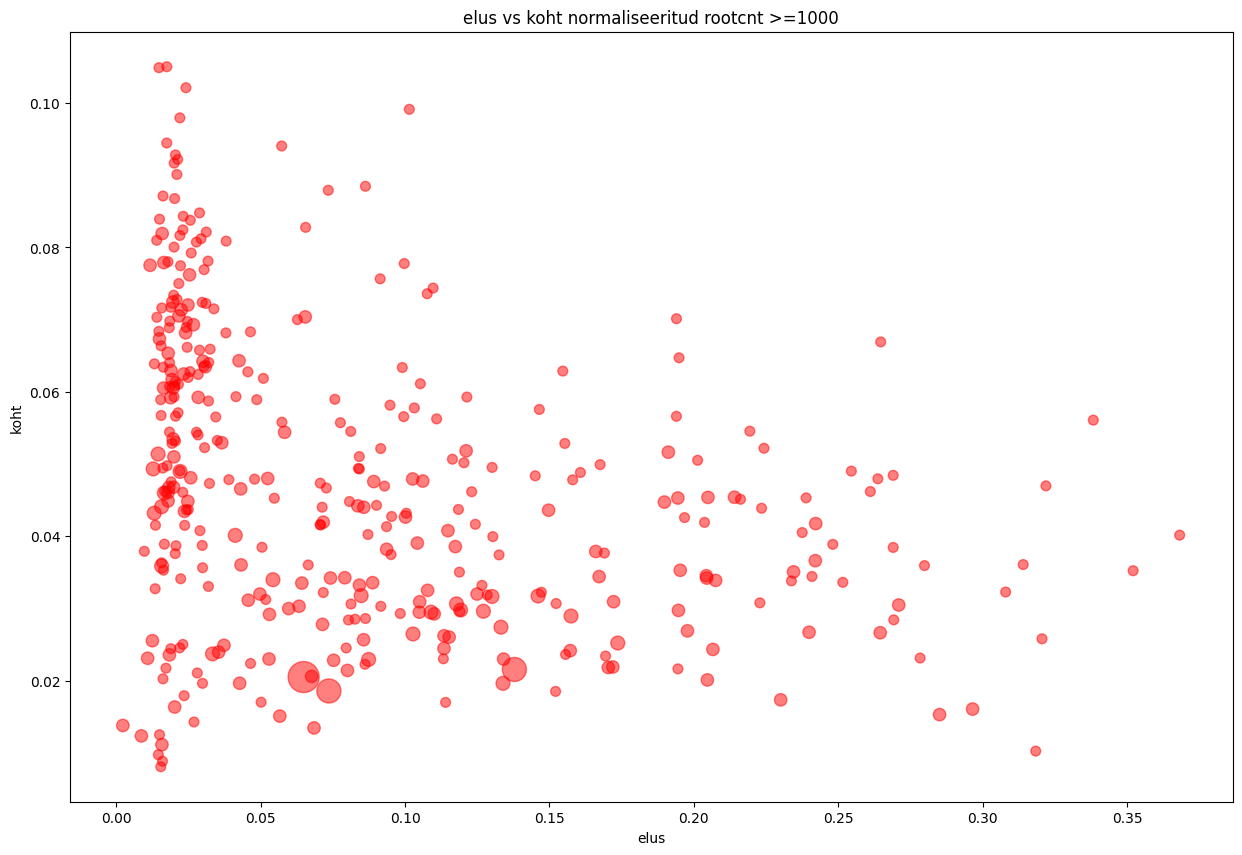

In [56]:
plt.figure(figsize=(15, 10))
x = elusad
y = kohad

#N = len(source3)
#colors = np.random.rand(N)

area = [areadict[cnt] for cnt in roots]

plt.scatter(x, y, s=area, c='r', alpha=0.5)


plt.title("elus vs koht normaliseeritud rootcnt >=1000")
plt.ylabel("koht")
plt.xlabel("elus")


plt.show()

### filter 1: root_cnt >=5000

In [57]:
elusad = []
kohad = []
roots = []

for i in range(len(source2)):
    if source2.iloc[i]["root_cnt"]>=5000:
        roots.append(source2.iloc[i]["root_cnt"])
        kohad.append(source2.iloc[i]["koht_cnt"]/source2.iloc[i]["root_cnt"])
        elusad.append(source2.iloc[i]["elus_cnt"]/source2.iloc[i]["root_cnt"])

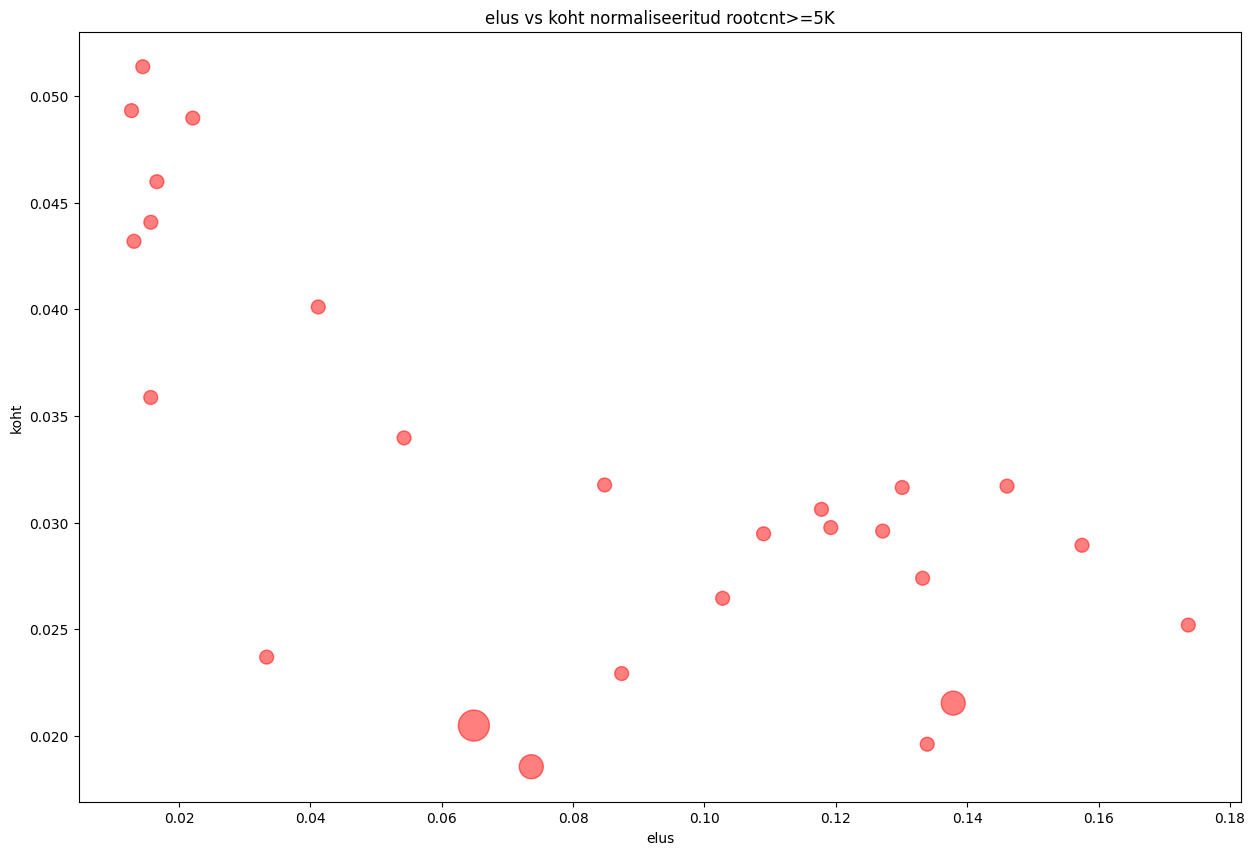

In [58]:
plt.figure(figsize=(15, 10))
x = elusad
y = kohad

#N = len(source3)
#colors = np.random.rand(N)

area = [areadict[cnt] for cnt in roots]

plt.scatter(x, y, s=area, c='r', alpha=0.5)


plt.title("elus vs koht normaliseeritud rootcnt>=5K")
plt.ylabel("koht")
plt.xlabel("elus")


plt.show()

### filter 1: root_cnt >=10000

In [59]:
elusad = []
kohad = []
roots = []

for i in range(len(source2)):
    if source2.iloc[i]["root_cnt"]>=10000:
        roots.append(source2.iloc[i]["root_cnt"])
        kohad.append(source2.iloc[i]["koht_cnt"]/source2.iloc[i]["root_cnt"])
        elusad.append(source2.iloc[i]["elus_cnt"]/source2.iloc[i]["root_cnt"])

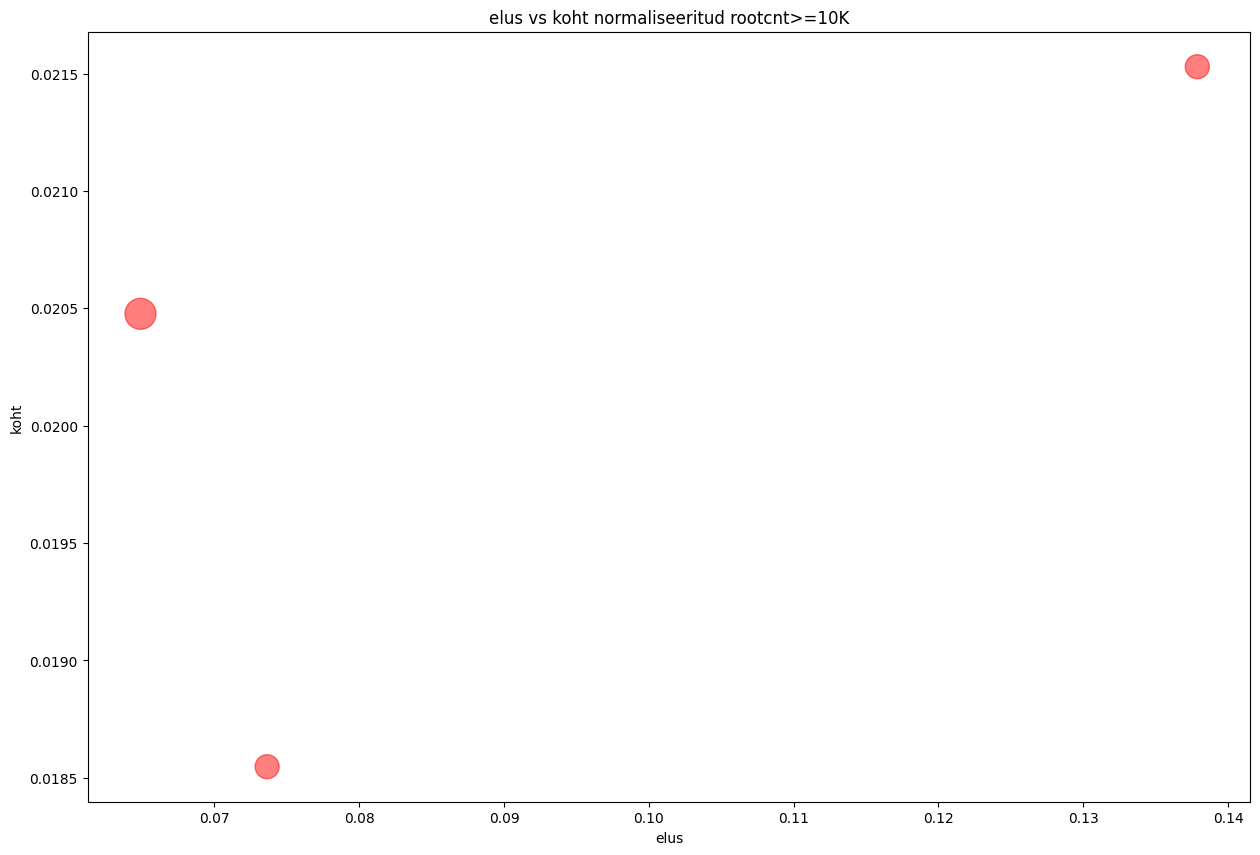

In [60]:
plt.figure(figsize=(15, 10))
x = elusad
y = kohad

#N = len(source3)
#colors = np.random.rand(N)

area = [areadict[cnt] for cnt in roots]

plt.scatter(x, y, s=area, c='r', alpha=0.5)


plt.title("elus vs koht normaliseeritud rootcnt>=10K")
plt.ylabel("koht")
plt.xlabel("elus")


plt.show()

In [ ]:
con.close()